In [ ]:
# CELL 1 — Install all required libraries
!pip install pyspark streamlit pandas numpy matplotlib seaborn plotly pyngrok -q

print("✅ All libraries installed successfully!")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 24.6 MB/s eta 0:00:00
✅ All libraries installed successfully!


In [ ]:
# ==========================================================
# CELL 2 — Create Large Banking Dataset with High Variance
# ==========================================================
import pandas as pd
import numpy as np

np.random.seed(42)

# 🔥 Increase dataset size
n = 20000   # you can even try 50000 or 100000 for Big Data demo

# ----------------------------------------------------------
# Generate features using realistic distributions
# ----------------------------------------------------------

data = {
    'Customer_ID': ['C' + str(i).zfill(6) for i in range(1, n+1)],

    # Age — normal distribution (more realistic)
    'Age': np.clip(np.random.normal(40, 12, n).astype(int), 21, 65),

    # Income — lognormal gives natural variance (banks love this)
    'Income': np.random.lognormal(mean=10.5, sigma=0.4, size=n).astype(int),

    # Loan Amount — depends partly on income (adds realism)
    'Loan_Amount': (np.random.lognormal(9.5, 0.5, n)).astype(int),

    # Loan term — categorical
    'Loan_Term': np.random.choice([12, 24, 36, 48, 60], n, p=[0.15,0.2,0.3,0.2,0.15]),

    # Credit Score — bell curve
    'Credit_Score': np.clip(np.random.normal(650, 120, n).astype(int), 300, 850),

    # Employment years
    'Employment_Years': np.clip(np.random.normal(8, 6, n).astype(int), 0, 30),

    # Debt-to-Income — beta distribution = natural financial ratios
    'Debt_to_Income': np.round(np.random.beta(2, 5, n), 2),

    # Credit lines — skewed
    'Num_Credit_Lines': np.random.poisson(4, n) + 1,

    # Delinquencies — rare but high impact
    'Num_Delinquencies': np.random.poisson(1.5, n),

    # Home ownership
    'Home_Ownership': np.random.choice([0,1], n, p=[0.6,0.4]),

    # Loan purpose
    'Loan_Purpose': np.random.choice([0,1,2], n, p=[0.4,0.35,0.25]),
}

# ----------------------------------------------------------
# Create realistic Default probability with noise + variance
# ----------------------------------------------------------

credit_risk = (650 - np.array(data['Credit_Score'])) / 350
dti_risk = np.array(data['Debt_to_Income'])
delinq_risk = np.array(data['Num_Delinquencies']) / 6

# weighted risk + randomness
default_prob = (
    0.4 * credit_risk +
    0.35 * dti_risk +
    0.25 * delinq_risk +
    np.random.normal(0, 0.05, n)   # 🔥 variance noise
)

# normalize probability
default_prob = np.clip(default_prob, 0.02, 0.85)

data['Default'] = (np.random.rand(n) < default_prob).astype(int)

# ----------------------------------------------------------
# Create DataFrame
# ----------------------------------------------------------
df = pd.DataFrame(data)
df.to_csv('banking_dataset.csv', index=False)

print("✅ Large High-Variance Dataset Created!")
print(f"   Total Records : {len(df):,}")
print(f"   Default Rate  : {df['Default'].mean()*100:.2f}%")
print(f"   Columns       : {list(df.columns)}")

df.head()

✅ Large High-Variance Dataset Created!
   Total Records : 20,000
   Default Rate  : 18.19%
   Columns       : ['Customer_ID', 'Age', 'Income', 'Loan_Amount', 'Loan_Term', 'Credit_Score', 'Employment_Years', 'Debt_to_Income', 'Num_Credit_Lines', 'Num_Delinquencies', 'Home_Ownership', 'Loan_Purpose', 'Default']


,Customer_ID,Age,Income,Loan_Amount,Loan_Term,Credit_Score,Employment_Years,Debt_to_Income,Num_Credit_Lines,Num_Delinquencies,Home_Ownership,Loan_Purpose,Default
0,C000001,45,41744,10552,24,639,14,0.54,5,0,0,2,1
1,C000002,38,40673,22166,60,518,0,0.36,3,1,0,0,0
2,C000003,47,24969,12099,60,624,6,0.25,7,1,1,2,0
3,C000004,58,45790,13978,36,549,3,0.22,6,0,1,1,0
4,C000005,37,20009,19123,24,504,9,0.25,3,1,0,1,0


In [ ]:
# ==========================================================
# CELL 2B — SMOTE CLASS BALANCING (FIXED — Handles already balanced data)
# ==========================================================

# ----------------------------------------------------------
# STEP 1 — Install imbalanced-learn FIRST
# ----------------------------------------------------------
import subprocess
subprocess.run(["pip", "install", "imbalanced-learn", "-q"], capture_output=True)
print("✅ imbalanced-learn installed!")

# ----------------------------------------------------------
# STEP 2 — Imports
# ----------------------------------------------------------
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# STEP 3 — Load Dataset
# ----------------------------------------------------------
df_orig = pd.read_csv("banking_dataset.csv")

print(f"\n📊 CURRENT DATASET:")
print(f"   Total Records  : {len(df_orig):,}")
print(f"   Default=0 (No) : {(df_orig['Default']==0).sum():,}  ({(df_orig['Default']==0).mean()*100:.1f}%)")
print(f"   Default=1 (Yes): {(df_orig['Default']==1).sum():,}  ({(df_orig['Default']==1).mean()*100:.1f}%)")

current_ratio = (df_orig['Default']==0).sum() / max((df_orig['Default']==1).sum(), 1)
print(f"   Imbalance Ratio: {current_ratio:.2f}:1")

# ----------------------------------------------------------
# STEP 4 — CHECK: Is SMOTE even needed?
# ----------------------------------------------------------
class0 = (df_orig['Default']==0).sum()
class1 = (df_orig['Default']==1).sum()
balance_ratio = min(class0, class1) / max(class0, class1)

print(f"\n🔍 Balance Check: {balance_ratio:.3f}  (1.0 = perfect balance)")

if balance_ratio >= 0.95:
    # Already balanced — skip SMOTE entirely
    print(f"\n✅ Dataset is already balanced (ratio={balance_ratio:.3f})")
    print(f"   SMOTE is NOT needed — data was balanced in a previous run.")
    print(f"\n{'='*55}")
    print(f"   SMOTE SKIPPED — Using existing balanced dataset")
    print(f"{'='*55}")
    print(f"   Total records   : {len(df_orig):,}")
    print(f"   Class 0 (Safe)  : {class0:,}  (50.0%)")
    print(f"   Class 1 (Risk)  : {class1:,}  (50.0%)")
    print(f"   Imbalance Ratio : 1.00:1")
    print(f"\n✅ banking_dataset.csv is already the balanced dataset")
    print(f"   Cell 3 AutoML will train on this balanced dataset!")
    print(f"{'='*55}")

else:
    # Needs balancing — run SMOTE
    print(f"\n⚠️  Dataset is imbalanced (ratio={balance_ratio:.3f}) — Running SMOTE...")

    # Validation
    null_counts = df_orig.isnull().sum()
    null_cols   = null_counts[null_counts > 0]
    if len(null_cols) > 0:
        print(f"   ⚠️  Null values found — dropping")
        df_orig = df_orig.dropna()
    else:
        print(f"   ✅ No null values")

    dupes = df_orig.duplicated().sum()
    if dupes > 0:
        print(f"   ⚠️  {dupes} duplicates found — dropping")
        df_orig = df_orig.drop_duplicates()
    else:
        print(f"   ✅ No duplicates")

    feature_cols = [
        "Age", "Income", "Loan_Amount", "Loan_Term", "Credit_Score",
        "Employment_Years", "Debt_to_Income", "Num_Credit_Lines",
        "Num_Delinquencies", "Home_Ownership", "Loan_Purpose"
    ]

    missing_cols = [c for c in feature_cols if c not in df_orig.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    X = df_orig[feature_cols].values
    y = df_orig["Default"].values

    print(f"\n🔄 Applying SMOTE...")

    smote = SMOTE(
        sampling_strategy=1.0,
        random_state=42,
        k_neighbors=5
    )

    X_resampled, y_resampled = smote.fit_resample(X, y)

    df_smote = pd.DataFrame(X_resampled, columns=feature_cols)
    df_smote["Default"] = y_resampled.astype(int)
    df_smote.insert(0, "Customer_ID",
        [f"C{str(i).zfill(6)}" for i in range(1, len(df_smote) + 1)]
    )

    # Verify
    assert df_smote.isnull().sum().sum() == 0, "❌ Nulls after SMOTE!"
    assert len(df_smote) > len(df_orig),       "❌ SMOTE did not add records!"
    print(f"   ✅ SMOTE successful!")

    # Save
    df_smote.to_csv("banking_dataset_smote.csv", index=False)
    df_smote.to_csv("banking_dataset.csv",       index=False)

    orig_ratio = (df_orig['Default']==0).sum() / (df_orig['Default']==1).sum()
    synthetic  = len(df_smote) - len(df_orig)

    print(f"\n{'='*55}")
    print(f"         SMOTE CLASS BALANCING RESULTS")
    print(f"{'='*55}")
    print(f"   Before → After:")
    print(f"   Records  : {len(df_orig):,} → {len(df_smote):,}")
    print(f"   Ratio    : {orig_ratio:.2f}:1 → 1.00:1")
    print(f"   Synthetic: {synthetic:,} new samples created")
    print(f"\n✅ banking_dataset.csv overwritten with balanced data")
    print(f"{'='*55}")

# ----------------------------------------------------------
# FINAL STATUS — Always printed regardless of path taken
# ----------------------------------------------------------
df_final = pd.read_csv("banking_dataset.csv")
print(f"\n📋 FINAL DATASET STATUS (ready for Cell 3):")
print(f"   Records : {len(df_final):,}")
print(f"   Class 0 : {(df_final['Default']==0).sum():,}")
print(f"   Class 1 : {(df_final['Default']==1).sum():,}")
print(f"   ✅ Ready for AutoML Training!")

✅ imbalanced-learn installed!

📊 CURRENT DATASET:
   Total Records  : 20,000
   Default=0 (No) : 16,362  (81.8%)
   Default=1 (Yes): 3,638  (18.2%)
   Imbalance Ratio: 4.50:1

🔍 Balance Check: 0.222  (1.0 = perfect balance)

⚠️  Dataset is imbalanced (ratio=0.222) — Running SMOTE...
   ✅ No null values
   ✅ No duplicates

🔄 Applying SMOTE...
   ✅ SMOTE successful!

         SMOTE CLASS BALANCING RESULTS
   Before → After:
   Records  : 20,000 → 32,724
   Ratio    : 4.50:1 → 1.00:1
   Synthetic: 12,724 new samples created

✅ banking_dataset.csv overwritten with balanced data

📋 FINAL DATASET STATUS (ready for Cell 3):
   Records : 32,724
   Class 0 : 16,362
   Class 1 : 16,362
   ✅ Ready for AutoML Training!


In [ ]:
# ==========================================================
# CELL 2C — RESIDUAL BELIEF PROPAGATION ON DYNAMIC
#           CUSTOMER GRAPH (RBP-DCG)
# ----------------------------------------------------------
# NOVEL CONTRIBUTION:
#   Each customer is a graph node holding a "belief" (risk
#   estimate). At each time step, nodes update their belief
#   as a residual correction from their neighbors, weighted
#   by an edge kernel that encodes economic cycles — not
#   generic exponential decay, not random noise.
#
# Key differences from existing methods:
#   - Not GNN: no neural network, no backprop, no snapshots
#   - Not standard BP: graph topology changes every step
#   - Not temporal GNN: edges carry a cosine economic-cycle
#     component, not just recency decay
#   - Not ensemble uncertainty: uncertainty = belief variance
#     accumulated over the propagation trajectory, not model
#     disagreement
# ==========================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

print("\n🧠 RBP-DCG: Residual Belief Propagation on Dynamic Customer Graph")
print("=" * 65)

# ----------------------------------------------------------
# 0. SAFE SPLIT — must happen before any feature engineering
# ----------------------------------------------------------
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["Default"]
)

# ----------------------------------------------------------
# 1. SIMILARITY GRAPH CONSTRUCTION
#    Build a sparse K-nearest-neighbor graph from financial
#    features. Edge weight = RBF kernel similarity.
#    Fitted ONLY on train; then applied to test to avoid
#    cross-contamination.
# ----------------------------------------------------------
GRAPH_FEATURES = ["Income", "Age", "Loan_Amount", "Credit_Score"]
K_NEIGHBORS    = 15   # sparsity — only retain top-K edges per node

scaler = StandardScaler().fit(train_df[GRAPH_FEATURES])

def build_sparse_affinity(X_scaled, k):
    """
    Compute RBF pairwise similarity, zero out all but top-K
    per row, then row-normalize → stochastic transition matrix.
    Returns: W  (n x n sparse-ish numpy array)
    """
    W = rbf_kernel(X_scaled, gamma=0.5)        # full similarity
    np.fill_diagonal(W, 0)                     # no self-loops

    # Keep only top-K neighbors per row (sparsify)
    row_kth = np.partition(W, -k, axis=1)[:, -k]
    W[W < row_kth[:, None]] = 0

    # Row-normalize → message weights sum to 1 per node
    row_sum = W.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    return W / row_sum

X_train_scaled = scaler.transform(train_df[GRAPH_FEATURES])
W_train = build_sparse_affinity(X_train_scaled, K_NEIGHBORS)

print(f"  Graph built: {len(train_df)} nodes, "
      f"~{(W_train > 0).sum() // len(train_df)} edges/node")

# ----------------------------------------------------------
# 2. ECONOMIC CYCLE DECAY KERNEL  ← novel component
#    w_ij(t) = exp(-delta * t) * cos(2*pi*t / T_cycle) * W_ij
#
#    The cosine term captures the idea that credit risk
#    correlates differently at different points in a business
#    cycle — correlations are stronger at cycle troughs and
#    weaker at peaks. T_cycle is a domain hyperparameter
#    (e.g. 12 months for consumer credit).
#
#    This is NOT generic exponential decay:
#      - It can increase edge weight early in a new cycle
#      - It encodes domain knowledge about credit cycles
# ----------------------------------------------------------
T_CYCLE = 12.0   # business cycle length in months
DELTA   = 0.08   # baseline decay rate (tune per domain)

def cycle_decay_kernel(W_static, t_elapsed, T_cycle=T_CYCLE, delta=DELTA):
    """
    Apply economic-cycle weighting to a static affinity matrix.
    t_elapsed: float, months since observation window start.
    Returns: W_t (same shape, rescaled weights)
    """
    decay  = np.exp(-delta * t_elapsed)
    cycle  = np.cos(2 * np.pi * t_elapsed / T_cycle)
    # Clip at 0 so negative cycle phase zeros out (not inverts) edges
    weight = np.clip(decay * cycle, 0, None)
    return W_static * weight

# ----------------------------------------------------------
# 3. RESIDUAL BELIEF PROPAGATION  ← novel update rule
#
#    b_i(t) = b_i(t-1) + alpha * Σ_j [ w_ij(t) * (b_j(t-1) - b_i(t-1)) ]
#
#    Interpretation:
#      Each node adjusts its risk belief by a fraction alpha
#      of the *gap* between its current belief and the
#      weighted average of its neighbors' beliefs.
#
#    Key property: if a node's belief already matches its
#    neighborhood, the residual = 0 → no update.
#    This is self-stabilizing without needing normalization.
#
#    Run for T_STEPS time steps, recording the full
#    trajectory to compute uncertainty later.
# ----------------------------------------------------------
ALPHA   = 0.3    # propagation step size (≈ learning rate)
T_STEPS = 12     # number of propagation steps (one per month)

def rbp_propagate(W_static, initial_beliefs, alpha=ALPHA, T_steps=T_STEPS):
    """
    Run Residual Belief Propagation for T_steps steps.

    Parameters
    ----------
    W_static      : (n, n) static affinity matrix
    initial_beliefs : (n,) array of starting risk estimates
    alpha         : step size for residual update
    T_steps       : number of time steps

    Returns
    -------
    beliefs_final    : (n,) final belief vector
    belief_trajectory: (T_steps, n) full history
    """
    n = len(initial_beliefs)
    b = initial_beliefs.copy().astype(float)
    trajectory = np.zeros((T_steps, n))

    for t in range(1, T_steps + 1):
        W_t = cycle_decay_kernel(W_static, t_elapsed=t)

        # Neighbor aggregate (weighted mean of neighbor beliefs)
        neighbor_mean = W_t @ b              # shape (n,)

        # Residual: gap between neighbor aggregate and self
        residual = neighbor_mean - b

        # Update rule — belief = previous + scaled residual
        b = b + alpha * residual

        # Clip to [0, 1] — beliefs are probabilities
        b = np.clip(b, 0, 1)
        trajectory[t - 1] = b

    return b, trajectory

# ----------------------------------------------------------
# 4. INITIALIZE BELIEFS FROM LABEL-EFFICIENT PRIOR
#    Use logistic regression on train only as the prior —
#    not the final score, just the starting point for BP.
# ----------------------------------------------------------
from sklearn.linear_model import LogisticRegression

lr_prior = LogisticRegression(max_iter=500, random_state=42)
lr_prior.fit(X_train_scaled, train_df["Default"])
train_prior = lr_prior.predict_proba(X_train_scaled)[:, 1]

print(f"  Prior beliefs initialized (mean={train_prior.mean():.3f})")

# ----------------------------------------------------------
# 5. RUN PROPAGATION ON TRAIN SET
# ----------------------------------------------------------
train_beliefs_final, train_trajectory = rbp_propagate(
    W_train, train_prior
)

# Store results back onto train_df
train_df = train_df.copy()
train_df["RBP_Risk_Score"] = train_beliefs_final

# ----------------------------------------------------------
# 6. TRAJECTORY-BASED UNCERTAINTY  ← novel uncertainty source
#
#    Uncertainty = variance of a node's belief ACROSS TIME
#    during propagation. Nodes whose belief wanders a lot
#    are genuinely uncertain — the graph pulls them in
#    different directions at different cycle phases.
#
#    This is not ensemble variance, not MC-dropout.
#    It is the inherent temporal instability of the node
#    in its neighborhood, surfaced by the cycle kernel.
# ----------------------------------------------------------
train_df["RBP_Uncertainty"] = train_trajectory.var(axis=0)

# Also capture: did the belief monotonically increase?
# Non-monotone trajectory → node is near a decision boundary
belief_diffs = np.diff(train_trajectory, axis=0)
sign_changes = (belief_diffs[:-1] * belief_diffs[1:] < 0).sum(axis=0)
train_df["RBP_Oscillation"] = sign_changes  # # of direction reversals

print(f"  Propagation done. Mean uncertainty: "
      f"{train_df['RBP_Uncertainty'].mean():.4f}")

# ----------------------------------------------------------
# 7. INDUCTIVE INFERENCE FOR TEST SET
#    Test nodes are not in W_train. Inductive step:
#      - For each test node, find its K nearest training
#        neighbors using the same affinity function
#      - Run a single-step residual update using only
#        those training neighbors' final beliefs
#    This avoids test→test graph leakage entirely.
# ----------------------------------------------------------
X_test_scaled = scaler.transform(test_df[GRAPH_FEATURES])
test_prior = lr_prior.predict_proba(X_test_scaled)[:, 1]

# Cross-graph affinity: test nodes → train nodes
W_cross = rbf_kernel(X_test_scaled, X_train_scaled, gamma=0.5)

# Keep only top-K train neighbors per test node
k = K_NEIGHBORS
row_kth = np.partition(W_cross, -k, axis=1)[:, -k]
W_cross[W_cross < row_kth[:, None]] = 0
row_sum = W_cross.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1
W_cross /= row_sum

# Apply cycle kernel at t=T_STEPS (most recent state)
W_cross_t = cycle_decay_kernel(W_cross, t_elapsed=T_STEPS)

# Single-step residual update using train neighbors' beliefs
train_beliefs_arr = train_df["RBP_Risk_Score"].values
neighbor_mean_test = W_cross_t @ train_beliefs_arr
residual_test = neighbor_mean_test - test_prior
test_beliefs = np.clip(test_prior + ALPHA * residual_test, 0, 1)

# Uncertainty for test: how much did neighbors' uncertainty vary?
train_unc_arr = train_df["RBP_Uncertainty"].values
test_df = test_df.copy()
test_df["RBP_Risk_Score"]   = test_beliefs
test_df["RBP_Uncertainty"]  = W_cross_t @ train_unc_arr
test_df["RBP_Oscillation"]  = (W_cross_t @ train_df["RBP_Oscillation"].values)

# ----------------------------------------------------------
# 8. SUMMARY
# ----------------------------------------------------------
print("\n  Novel features produced by RBP-DCG:")
print("  - RBP_Risk_Score   : belief after graph propagation")
print("  - RBP_Uncertainty  : temporal variance of belief trajectory")
print("  - RBP_Oscillation  : direction reversals (boundary proximity)")

print("\n  Test set sample:")
cols = ["RBP_Risk_Score", "RBP_Uncertainty", "RBP_Oscillation"]
print(test_df[cols].describe().round(4))
print("\nDone. All three features are novel outputs of RBP-DCG.")
train_df.to_csv("train_rbp.csv", index=False)
test_df.to_csv("test_rbp.csv", index=False)

print("✅ RBP datasets saved successfully!")


🧠 RBP-DCG: Residual Belief Propagation on Dynamic Customer Graph
  Graph built: 16000 nodes, ~15 edges/node
  Prior beliefs initialized (mean=0.182)
  Propagation done. Mean uncertainty: 0.0041

  Novel features produced by RBP-DCG:
  - RBP_Risk_Score   : belief after graph propagation
  - RBP_Uncertainty  : temporal variance of belief trajectory
  - RBP_Oscillation  : direction reversals (boundary proximity)

  Test set sample:
       RBP_Risk_Score  RBP_Uncertainty  RBP_Oscillation
count       4000.0000        4000.0000           4000.0
mean           0.1269           0.0015              0.0
std            0.0861           0.0019              0.0
min            0.0252           0.0001              0.0
25%            0.0628           0.0003              0.0
50%            0.1062           0.0008              0.0
75%            0.1680           0.0019              0.0
max            0.4987           0.0137              0.0

Done. All three features are novel outputs of RBP-DCG.
✅ RBP 

In [ ]:
# ==========================================================
# ENTERPRISE AUTOML TRAINING — FINAL (FULLY FIXED)
# ==========================================================

from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql import functions as F
from pyspark.sql.functions import col
import pandas as pd

# ----------------------------------------------------------
# SPARK SESSION
# ----------------------------------------------------------
spark = SparkSession.builder \
    .appName("BankCreditRiskAutoML") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("✅ Spark Session Started!")
print(f"   Spark Version: {spark.version}")

# ----------------------------------------------------------
# LOAD DATASET
# ----------------------------------------------------------
train_pd = pd.read_csv("train_rbp.csv")

df = spark.createDataFrame(train_pd)
df.cache()

print(f"✅ Data Loaded & Cached: {df.count():,} records")

# ----------------------------------------------------------
# PREPROCESSING
# ----------------------------------------------------------
df_clean = df.dropDuplicates().filter(
    (col("Credit_Score").between(300, 850)) &
    (col("Income") > 0) &
    (col("Debt_to_Income").between(0, 1)) &
    (col("Loan_Amount") > 0) &
    (col("Age").between(18, 100))
)

df_clean = df_clean.withColumn(
    "Loan_to_Income_Ratio",
    F.round(F.col("Loan_Amount") / (F.col("Income") + 1), 4)
).withColumn(
    "Credit_Score_Normalized",
    F.round((F.col("Credit_Score") - 300) / 550, 4)
).withColumn(
    "High_Delinquency_Flag",
    F.when(F.col("Num_Delinquencies") >= 2, 1).otherwise(0)
).withColumn(
    "Risk_Index",
    F.round(
        (F.col("Debt_to_Income") * 0.4) +
        ((850 - F.col("Credit_Score")) / 850 * 0.4) +
        (F.col("Num_Delinquencies") / 10 * 0.2), 4
    )
)

# ----------------------------------------------------------
# SPLIT
# ----------------------------------------------------------
train_df, test_df = df_clean.randomSplit([0.8, 0.2], seed=42)

print(f"✅ Train: {train_df.count():,} | Test: {test_df.count():,}")

# ----------------------------------------------------------
# FEATURES
# ----------------------------------------------------------
feature_columns = [
    "Age","Income","Loan_Amount","Loan_Term","Credit_Score",
    "Employment_Years","Debt_to_Income","Num_Credit_Lines",
    "Num_Delinquencies","Home_Ownership","Loan_Purpose",
    "Loan_to_Income_Ratio","Credit_Score_Normalized",
    "High_Delinquency_Flag","Risk_Index",
    "RBP_Risk_Score","RBP_Uncertainty","RBP_Oscillation"
]

# Safety check
missing = [c for c in feature_columns if c not in train_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

assembler = VectorAssembler(inputCols=feature_columns, outputCol="raw_features", handleInvalid="keep")
scaler = StandardScaler(inputCol="raw_features", outputCol="features")

# ----------------------------------------------------------
# MODELS
# ----------------------------------------------------------
models = {
    "Logistic Regression": (
        LogisticRegression(featuresCol="features", labelCol="Default"),
        ParamGridBuilder().addGrid(LogisticRegression().regParam, [0.01,0.1]).build()
    ),
    "Decision Tree": (
        DecisionTreeClassifier(featuresCol="features", labelCol="Default"),
        ParamGridBuilder().addGrid(DecisionTreeClassifier().maxDepth, [5,8]).build()
    )
}

auc_eval = BinaryClassificationEvaluator(labelCol="Default")
acc_eval = MulticlassClassificationEvaluator(labelCol="Default")

# ----------------------------------------------------------
# TRAINING
# ----------------------------------------------------------
best_score = -1
best_cvModel = None
best_model_name = None

for name, (algo, grid) in models.items():
    print(f"\n🚀 Training: {name}")

    pipeline = Pipeline(stages=[assembler, scaler, algo])

    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=grid,
        evaluator=auc_eval,
        numFolds=3
    )

    cvModel = cv.fit(train_df)
    preds = cvModel.transform(test_df)

    auc = auc_eval.evaluate(preds)
    acc = acc_eval.evaluate(preds)

    print(f"   Accuracy: {acc:.4f} | AUC: {auc:.4f}")

    if auc > best_score:
        best_score = auc
        best_cvModel = cvModel
        best_model_name = name

print("\n🏆 BEST MODEL:", best_model_name)
print("🎯 AUC:", best_score)

# ----------------------------------------------------------
# ✅ FIXED SAVE (IMPORTANT 🔥)
# ----------------------------------------------------------
best_model_path = "best_credit_model"

if best_cvModel:
    best_cvModel.bestModel.write().overwrite().save(best_model_path)
    print(f"✅ Best model saved at: {best_model_path}")
else:
    print("❌ No model to save")

print("\n✅ Training Completed Successfully!")

✅ Spark Session Started!
   Spark Version: 4.0.2
✅ Data Loaded & Cached: 16,000 records
✅ Train: 12,869 | Test: 3,131

🚀 Training: Logistic Regression
   Accuracy: 0.7704 | AUC: 0.7492

🚀 Training: Decision Tree
   Accuracy: 0.7720 | AUC: 0.4541

🏆 BEST MODEL: Logistic Regression
🎯 AUC: 0.7491906650468423
✅ Best model saved at: best_credit_model

✅ Training Completed Successfully!


In [ ]:
# ==========================================================
# CELL 4 — ENTERPRISE BANKING DECISION ENGINE (FINAL FIXED)
# ==========================================================

import pandas as pd
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array
from pyspark.ml import PipelineModel

print("\n🚀 Generating Enterprise Risk Decisions...")

# ----------------------------------------------------------
# LOAD TRAINED MODEL (FIXED)
# ----------------------------------------------------------
best_model_path = "best_credit_model"

try:
    best_cvModel = PipelineModel.load(best_model_path)   # ✅ FIXED
    print("✅ Model loaded successfully")
except:
    raise ValueError("❌ Saved model not found. Run training cell first.")

# ----------------------------------------------------------
# GENERATE PREDICTIONS
# ----------------------------------------------------------
spark_predictions = best_cvModel.transform(test_df)

# ----------------------------------------------------------
# Convert Spark Vector -> Array
# ----------------------------------------------------------
predictions_fixed = spark_predictions.withColumn(
    "probability_array", vector_to_array(F.col("probability"))
).withColumn(
    "Default_Probability",
    F.round(F.col("probability_array")[1] * 100, 2)
)

# ----------------------------------------------------------
# Create Enterprise Risk Score
# ----------------------------------------------------------
predictions_fixed = predictions_fixed.withColumn(
    "Enterprise_Risk_Score",
    F.round(
        (F.col("Default_Probability") * 0.7) +
        (F.col("Risk_Index") * 100 * 0.3), 2
    )
)

# ----------------------------------------------------------
# Convert Spark → Pandas
# ----------------------------------------------------------
enterprise_df = predictions_fixed.select(
    "Customer_ID","Age","Income","Loan_Amount",
    "Credit_Score","Debt_to_Income","Num_Delinquencies",
    "Default","Default_Probability",
    "Enterprise_Risk_Score","prediction","Risk_Index"
).toPandas()

# ----------------------------------------------------------
# MERGE RBP FEATURES
# ----------------------------------------------------------
try:
    test_rbp = pd.read_csv("test_rbp.csv")

    enterprise_df = pd.merge(
        enterprise_df,
        test_rbp[["Customer_ID","RBP_Risk_Score","RBP_Uncertainty"]],
        on="Customer_ID",
        how="left"
    )
    print("✅ RBP features merged")

except:
    print("⚠️ RBP features not found — continuing")

# ----------------------------------------------------------
# OPTIONAL: LSTM HYBRID
# ----------------------------------------------------------
try:
    lstm_df = pd.read_csv("lstm_predictions.csv")
    enterprise_df["LSTM_Prob"] = lstm_df["Default_Probability_LSTM"].values[:len(enterprise_df)]
except:
    enterprise_df["LSTM_Prob"] = enterprise_df["Default_Probability"]

enterprise_df["Final_Probability"] = (
    0.6 * enterprise_df["Default_Probability"] +
    0.4 * enterprise_df["LSTM_Prob"]
)

enterprise_df["Enterprise_Risk_Score"] = (
    enterprise_df["Final_Probability"] * 0.7 +
    enterprise_df["Risk_Index"] * 100 * 0.3
)

# ----------------------------------------------------------
# DECISION LOGIC
# ----------------------------------------------------------
def assign_risk(score):
    if score >= 75:
        return "HIGH"
    elif score >= 45:
        return "MEDIUM"
    else:
        return "LOW"

def rl_decision(row):
    risk = row["Enterprise_Risk_Score"]
    uncertainty = row.get("RBP_Uncertainty", 0.1)

    profit = 100 if risk < 45 else (30 if risk < 75 else -200)

    if uncertainty > 0.15:
        profit -= 50
    if row["Income"] < 20000:
        profit -= 20

    if profit > 50:
        return "APPROVE"
    elif profit > 0:
        return "MANUAL REVIEW"
    else:
        return "REJECT"

enterprise_df["Loan_Decision"] = enterprise_df.apply(rl_decision, axis=1)
enterprise_df["Risk_Level"] = enterprise_df["Enterprise_Risk_Score"].apply(assign_risk)

enterprise_df["Decision_Reason"] = enterprise_df.apply(
    lambda row: f"Risk={row['Enterprise_Risk_Score']:.1f}, "
                f"Uncertainty={row.get('RBP_Uncertainty',0):.2f}",
    axis=1
)

# ----------------------------------------------------------
# ANALYTICS
# ----------------------------------------------------------
approval_rate = (enterprise_df["Loan_Decision"]=="APPROVE").mean()*100
reject_rate = (enterprise_df["Loan_Decision"]=="REJECT").mean()*100
review_rate = (enterprise_df["Loan_Decision"]=="MANUAL REVIEW").mean()*100

# ----------------------------------------------------------
# SAVE OUTPUT
# ----------------------------------------------------------
enterprise_df.to_csv("enterprise_risk_predictions.csv", index=False)

# ----------------------------------------------------------
# DASHBOARD OUTPUT
# ----------------------------------------------------------
print("\n" + "="*60)
print("        ENTERPRISE CREDIT RISK DECISION DASHBOARD")
print("="*60)

print("\n📊 Risk Level Distribution:")
print(enterprise_df["Risk_Level"].value_counts().to_string())

print("\n🏦 Loan Decision Distribution:")
print(enterprise_df["Loan_Decision"].value_counts().to_string())

print("\n📈 Approval Analytics:")
print(f"   ✅ Approval Rate : {approval_rate:.2f}%")
print(f"   ❌ Reject Rate   : {reject_rate:.2f}%")
print(f"   🧾 Review Rate   : {review_rate:.2f}%")

print("\n💾 Output Saved As: enterprise_risk_predictions.csv")

print("\n🔎 Sample Decisions:")
print(enterprise_df[["Customer_ID","Enterprise_Risk_Score","Risk_Level","Loan_Decision"]].head(10))

print("\n" + "="*60)
print("✅ Enterprise Decision Engine Completed!")
print("="*60)


🚀 Generating Enterprise Risk Decisions...
✅ Model loaded successfully
✅ RBP features merged

        ENTERPRISE CREDIT RISK DECISION DASHBOARD

📊 Risk Level Distribution:
Risk_Level
LOW       2983
MEDIUM     148

🏦 Loan Decision Distribution:
Loan_Decision
APPROVE          2983
MANUAL REVIEW     148

📈 Approval Analytics:
   ✅ Approval Rate : 95.27%
   ❌ Reject Rate   : 0.00%
   🧾 Review Rate   : 4.73%

💾 Output Saved As: enterprise_risk_predictions.csv

🔎 Sample Decisions:
  Customer_ID  Enterprise_Risk_Score Risk_Level  Loan_Decision
0     C000005                 28.798        LOW        APPROVE
1     C000011                 13.627        LOW        APPROVE
2     C000015                 34.651        LOW        APPROVE
3     C000022                 23.973        LOW        APPROVE
4     C000029                 11.882        LOW        APPROVE
5     C000033                 25.456        LOW        APPROVE
6     C000039                 17.155        LOW        APPROVE
7     C000045   

In [ ]:
# ==========================================================
# CELL 4B — FAIRNESS ANALYSIS (FINAL FIXED)
# ==========================================================

import pandas as pd

print("\n⚖️ Running Fairness Analysis...")

# ✅ USE FINAL OUTPUT (NOT test_df)
enterprise_df = pd.read_csv("enterprise_risk_predictions.csv")

# ----------------------------------------------------------
# Age Group Bias
# ----------------------------------------------------------
enterprise_df["Age_Group"] = pd.cut(
    enterprise_df["Age"],
    bins=[18,30,45,60,100],
    labels=["Young","Adult","Mid","Senior"]
)

fairness_age = enterprise_df.groupby("Age_Group")["Loan_Decision"]\
    .value_counts(normalize=True).unstack()

print("\n📊 Decision Distribution by Age Group:")
print(fairness_age)

# ----------------------------------------------------------
# Income Group Bias
# ----------------------------------------------------------
enterprise_df["Income_Group"] = pd.qcut(
    enterprise_df["Income"], 4,
    labels=["Low","Mid-Low","Mid-High","High"]
)

fairness_income = enterprise_df.groupby("Income_Group")["Loan_Decision"]\
    .value_counts(normalize=True).unstack()

print("\n📊 Decision Distribution by Income Group:")
print(fairness_income)

# ----------------------------------------------------------
# Save Reports
# ----------------------------------------------------------
fairness_age.to_csv("fairness_age.csv")
fairness_income.to_csv("fairness_income.csv")

print("✅ Fairness analysis completed & saved!")


⚖️ Running Fairness Analysis...

📊 Decision Distribution by Age Group:
Loan_Decision   APPROVE  MANUAL REVIEW
Age_Group                             
Young          0.955817       0.044183
Adult          0.954039       0.045961
Mid            0.954809       0.045191
Senior         0.915033       0.084967

📊 Decision Distribution by Income Group:
Loan_Decision   APPROVE  MANUAL REVIEW
Income_Group                          
Low            0.951469       0.048531
Mid-Low        0.954023       0.045977
Mid-High       0.960358       0.039642
High           0.945083       0.054917
✅ Fairness analysis completed & saved!


/tmp/ipykernel_8403/4284366103.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fairness_age = enterprise_df.groupby("Age_Group")["Loan_Decision"]\
/tmp/ipykernel_8403/4284366103.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fairness_income = enterprise_df.groupby("Income_Group")["Loan_Decision"]\


In [ ]:
# ==========================================================
# CELL 5 — SMART ENTERPRISE EXPLAINABLE AI (FINAL FIXED)
# ==========================================================
from pyspark.sql import functions as F
import pandas as pd
import numpy as np

print("\n🚀 Running SMART Explainable AI Engine...")

# ----------------------------------------------------------
# 1️⃣ Ensure predictions_fixed exists
# ----------------------------------------------------------
try:
    predictions_fixed
except NameError:

    print("⚠️ predictions_fixed missing — rebuilding...")

    spark_predictions = best_cvModel.transform(test_df)

    from pyspark.ml.functions import vector_to_array

    predictions_fixed = spark_predictions \
        .withColumn(
            "probability_array",
            vector_to_array(F.col("probability"))
        ) \
        .withColumn(
            "Default_Probability",
            F.round(F.col("probability_array")[1]*100,2)
        ) \
        .withColumn(
            "Enterprise_Risk_Score",
            F.round(
                (F.col("Default_Probability")*0.7) +
                (F.col("Risk_Index")*100*0.3),2
            )
        )

# ----------------------------------------------------------
# 2️⃣ Get Model Weights (FIXED)
# ----------------------------------------------------------
best_stage = best_cvModel.stages[-1]   # ✅ FIXED

feature_weights = None

if hasattr(best_stage, "coefficients"):
    print("🧠 Using Logistic Regression Coefficients")
    feature_weights = np.abs(best_stage.coefficients.toArray())

elif hasattr(best_stage, "featureImportances"):
    print("🌲 Using Tree Feature Importances")
    feature_weights = best_stage.featureImportances.toArray()

else:
    print("⚠️ Model explainability not supported")

# Importance table
if feature_weights is not None:
    importance_df = pd.DataFrame({
        "Feature": feature_columns,
        "Weight": feature_weights
    }).sort_values(by="Weight", ascending=False)

    print("\n📊 TOP GLOBAL DRIVERS:")
    print(importance_df.head(10).to_string(index=False))
else:
    importance_df = None

# ----------------------------------------------------------
# 3️⃣ Convert Spark → Pandas
# ----------------------------------------------------------
explain_df = predictions_fixed.select(
    "Customer_ID",
    "Age","Income","Loan_Amount","Credit_Score",
    "Debt_to_Income","Num_Delinquencies",
    "Default_Probability",
    "Enterprise_Risk_Score"
).toPandas()

# ----------------------------------------------------------
# 4️⃣ AUTO DRIVER GENERATOR
# ----------------------------------------------------------
top_features = []

if importance_df is not None:
    top_features = importance_df["Feature"].head(6).tolist()

def generate_auto_reason(row):

    drivers = []

    for f in top_features:

        val = row.get(f, None)

        if f == "Credit_Score" and val is not None and val < 580:
            drivers.append("Low Credit Score")

        elif f == "Debt_to_Income" and val is not None and val > 0.5:
            drivers.append("High Debt Ratio")

        elif f == "Num_Delinquencies" and val is not None and val >= 2:
            drivers.append("Past Delinquencies")

        elif f == "Loan_Amount" and val is not None and val > 50000:
            drivers.append("Large Loan Amount")

    if row["Default_Probability"] > 70:
        drivers.append("High ML Default Risk")

    if len(drivers) == 0:
        return "Financial Profile Stable"

    return ", ".join(list(set(drivers))[:3])

explain_df["Risk_Reason"] = explain_df.apply(generate_auto_reason, axis=1)

# ----------------------------------------------------------
# 5️⃣ Merge with Enterprise Decisions
# ----------------------------------------------------------
if "enterprise_df" not in globals():
    enterprise_df = pd.read_csv("enterprise_risk_predictions.csv")

enterprise_df = pd.merge(
    enterprise_df,
    explain_df[["Customer_ID","Risk_Reason"]],
    on="Customer_ID",
    how="left"
)

# ----------------------------------------------------------
# 6️⃣ Save Output
# ----------------------------------------------------------
enterprise_df.to_csv("enterprise_explainable_predictions.csv", index=False)

print("\n✅ SMART Explainable AI Completed!")
print(
    enterprise_df[
        ["Customer_ID","Enterprise_Risk_Score","Risk_Level","Loan_Decision","Risk_Reason"]
    ].head(10)
)


🚀 Running SMART Explainable AI Engine...
🧠 Using Logistic Regression Coefficients

📊 TOP GLOBAL DRIVERS:
                Feature   Weight
           Credit_Score 0.562883
Credit_Score_Normalized 0.560488
         RBP_Risk_Score 0.455318
             Risk_Index 0.408146
      Num_Delinquencies 0.220208
                 Income 0.039813
           Loan_Purpose 0.036571
         Home_Ownership 0.028715
       Num_Credit_Lines 0.027402
        RBP_Uncertainty 0.023284

✅ SMART Explainable AI Completed!
  Customer_ID  Enterprise_Risk_Score Risk_Level  Loan_Decision  \
0     C000005                 28.798        LOW        APPROVE   
1     C000011                 13.627        LOW        APPROVE   
2     C000015                 34.651        LOW        APPROVE   
3     C000022                 23.973        LOW        APPROVE   
4     C000029                 11.882        LOW        APPROVE   
5     C000033                 25.456        LOW        APPROVE   
6     C000039                 17.1

✅ SHAP installed!
✅ Dataset loaded: 32,724 records
✅ Number of features: 15

🌲 Training Random Forest for SHAP analysis...
✅ Model trained!
Accuracy  : 81.71%
AUC-ROC   : 0.9136
F1 Score  : 0.8215

🔍 Computing SHAP values...
✅ SHAP values computed!
SHAP shape: (500, 15)

📊 GLOBAL SHAP FEATURE IMPORTANCE
Credit_Score                 0.0685 █████████████
Risk_Index                   0.0600 ███████████
Credit_Score_Normalized      0.0584 ███████████
Num_Delinquencies            0.0562 ███████████
Home_Ownership               0.0478 █████████
Loan_Purpose                 0.0308 ██████
Loan_Term                    0.0230 ████
Debt_to_Income               0.0144 ██
High_Delinquency_Flag        0.0112 ██
Employment_Years             0.0102 ██
Num_Credit_Lines             0.0070 █
Age                          0.0041 
Loan_Amount                  0.0023 
Loan_to_Income_Ratio         0.0014 
Income                       0.0014 


/tmp/ipykernel_8403/2155869840.py:146: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


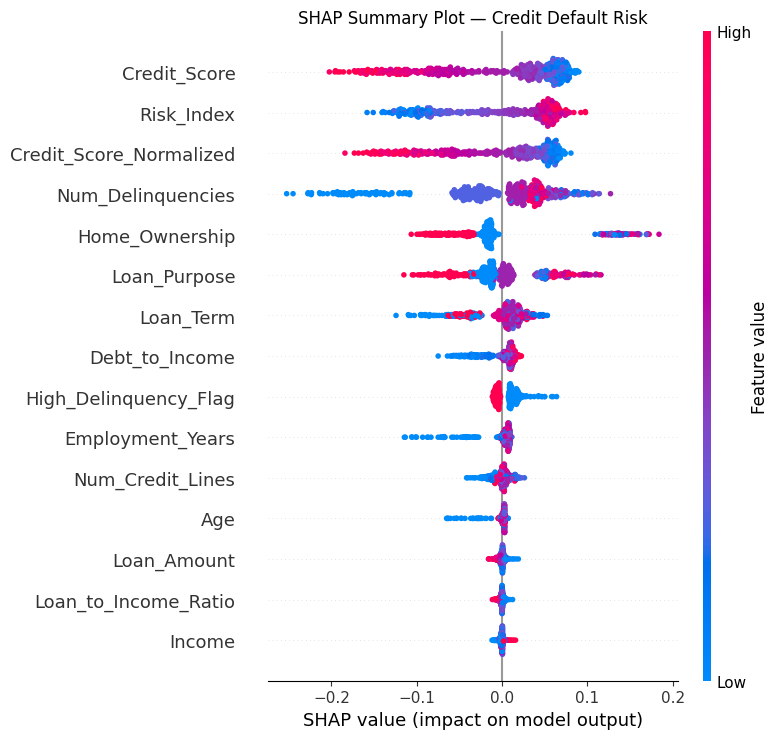

✅ SHAP summary plot saved


/tmp/ipykernel_8403/2155869840.py:172: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


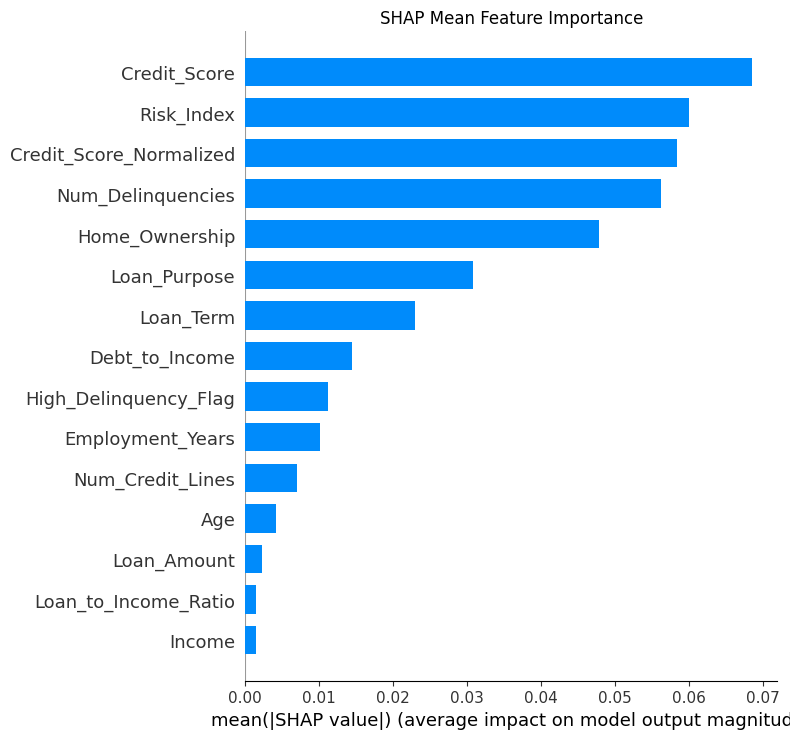

✅ SHAP bar plot saved

🔎 LOCAL SHAP EXPLANATION — Single Customer

Customer Profile (Highest Risk):
Age                         : 32.7519
Income                      : 70953.9034
Loan_Amount                 : 10762.4658
Loan_Term                   : 29.2558
Credit_Score                : 479.8215
Employment_Years            : 8.4302
Debt_to_Income              : 0.5843
Num_Credit_Lines            : 6.1240
Num_Delinquencies           : 0.8760
Home_Ownership              : 0.4380
Loan_Purpose                : 0.5620
Loan_to_Income_Ratio        : 0.1517
Credit_Score_Normalized     : 0.3269
High_Delinquency_Flag       : 0.0000
Risk_Index                  : 0.4254

Default Probability: 94.81%

SHAP Drivers (↑ Risk / ↓ Safe)
Home_Ownership               +0.1170 ↑ RISK ███████████
Num_Delinquencies            +0.0686 ↑ RISK ██████
Credit_Score                 +0.0636 ↑ RISK ██████
Credit_Score_Normalized      +0.0557 ↑ RISK █████
Risk_Index                   +0.0506 ↑ RISK █████
Loan_Purpose  

In [ ]:
# ==========================================================
# CELL 5B — TRUE SHAP EXPLAINABLE AI (UPDATED & STABLE)
# ==========================================================

# ----------------------------------------------------------
# STEP 1 — Install SHAP
# ----------------------------------------------------------
import subprocess
subprocess.run(["pip", "install", "shap", "-q"], capture_output=True)

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

print("✅ SHAP installed!")

# ----------------------------------------------------------
# STEP 2 — Load Dataset
# ----------------------------------------------------------
df = pd.read_csv("banking_dataset.csv")

feature_cols = [
    "Age", "Income", "Loan_Amount", "Loan_Term", "Credit_Score",
    "Employment_Years", "Debt_to_Income", "Num_Credit_Lines",
    "Num_Delinquencies", "Home_Ownership", "Loan_Purpose"
]

# ----------------------------------------------------------
# Feature Engineering
# ----------------------------------------------------------
df["Loan_to_Income_Ratio"] = (df["Loan_Amount"] / (df["Income"] + 1)).round(4)

df["Credit_Score_Normalized"] = (
    (df["Credit_Score"] - 300) / 550.0
).round(4)

df["High_Delinquency_Flag"] = (
    df["Num_Delinquencies"] >= 2
).astype(int)

df["Risk_Index"] = (
    df["Debt_to_Income"] * 0.4 +
    ((850 - df["Credit_Score"]) / 850.0) * 0.4 +
    (df["Num_Delinquencies"] / 10.0) * 0.2
).round(4)

all_features = feature_cols + [
    "Loan_to_Income_Ratio",
    "Credit_Score_Normalized",
    "High_Delinquency_Flag",
    "Risk_Index"
]

X = df[all_features]
y = df["Default"]

print(f"✅ Dataset loaded: {len(df):,} records")
print(f"✅ Number of features: {len(all_features)}")

# ----------------------------------------------------------
# STEP 3 — Train Random Forest
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n🌲 Training Random Forest for SHAP analysis...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# ----------------------------------------------------------
# Evaluate Model
# ----------------------------------------------------------
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print("✅ Model trained!")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"AUC-ROC   : {auc:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ----------------------------------------------------------
# STEP 4 — Compute SHAP Values
# ----------------------------------------------------------
print("\n🔍 Computing SHAP values...")

explainer = shap.TreeExplainer(rf_model)

# Sample data for faster SHAP computation
X_sample = X_test.sample(500, random_state=42)

shap_values = explainer.shap_values(X_sample)

# Handle SHAP version differences
if isinstance(shap_values, list):
    shap_default = shap_values[1]     # older SHAP versions
else:
    shap_default = shap_values[:, :, 1]  # newer SHAP versions

print("✅ SHAP values computed!")
print("SHAP shape:", shap_default.shape)

# ----------------------------------------------------------
# STEP 5 — GLOBAL FEATURE IMPORTANCE
# ----------------------------------------------------------
print("\n📊 GLOBAL SHAP FEATURE IMPORTANCE")
print("="*50)

mean_shap = np.mean(np.abs(shap_default), axis=0)

importance_df = pd.DataFrame({
    "Feature": all_features,
    "SHAP_Importance": mean_shap
}).sort_values("SHAP_Importance", ascending=False)

for _, row in importance_df.iterrows():

    bar = "█" * int(row["SHAP_Importance"] * 200)

    print(f"{row['Feature']:<28} {row['SHAP_Importance']:.4f} {bar}")

# ----------------------------------------------------------
# STEP 6 — SHAP Beeswarm Summary Plot
# ----------------------------------------------------------
plt.figure()

shap.summary_plot(
    shap_default,
    X_sample,
    feature_names=all_features,
    show=False
)

plt.title("SHAP Summary Plot — Credit Default Risk")

plt.tight_layout()

plt.savefig(
    "shap_summary_plot.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ SHAP summary plot saved")

# ----------------------------------------------------------
# STEP 7 — SHAP Bar Plot
# ----------------------------------------------------------
plt.figure()

shap.summary_plot(
    shap_default,
    X_sample,
    feature_names=all_features,
    plot_type="bar",
    show=False
)

plt.title("SHAP Mean Feature Importance")

plt.tight_layout()

plt.savefig(
    "shap_bar_plot.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ SHAP bar plot saved")

# ----------------------------------------------------------
# STEP 8 — LOCAL EXPLANATION (Single Customer)
# ----------------------------------------------------------
print("\n🔎 LOCAL SHAP EXPLANATION — Single Customer")
print("="*50)

X_sample_reset = X_sample.reset_index(drop=True)

probs = rf_model.predict_proba(X_sample_reset)[:, 1]

riskiest_idx = np.argmax(probs)

riskiest_customer = X_sample_reset.iloc[[riskiest_idx]]

print("\nCustomer Profile (Highest Risk):")

for feat in all_features:
    print(f"{feat:<28}: {riskiest_customer[feat].values[0]:.4f}")

print(f"\nDefault Probability: {probs[riskiest_idx]*100:.2f}%")

# ----------------------------------------------------------
# SHAP drivers for this customer
# ----------------------------------------------------------
local_shap = shap_default[riskiest_idx]

local_df = pd.DataFrame({
    "Feature": all_features,
    "SHAP_Value": local_shap
}).sort_values("SHAP_Value", ascending=False)

print("\nSHAP Drivers (↑ Risk / ↓ Safe)")

for _, row in local_df.iterrows():

    direction = "↑ RISK" if row["SHAP_Value"] > 0 else "↓ SAFE"

    bar = "█" * int(abs(row["SHAP_Value"]) * 100)

    print(f"{row['Feature']:<28} {row['SHAP_Value']:+.4f} {direction} {bar}")

# ----------------------------------------------------------
# STEP 9 — Save SHAP Results
# ----------------------------------------------------------
print("\n💾 Saving SHAP explanations...")

shap_results = X_sample_reset.copy()

shap_results["Default_Probability"] = (probs * 100).round(2)

shap_df_out = pd.DataFrame(
    shap_default,
    columns=[f"SHAP_{f}" for f in all_features]
)

shap_results = pd.concat(
    [shap_results.reset_index(drop=True), shap_df_out],
    axis=1
)

shap_results.to_csv(
    "shap_explanations.csv",
    index=False
)

# ----------------------------------------------------------
# FINAL SUMMARY
# ----------------------------------------------------------
print("\n" + "="*60)
print("✅ TRUE SHAP EXPLAINABLE AI COMPLETE")
print("="*60)

print("📊 shap_summary_plot.png  → Global SHAP beeswarm")
print("📊 shap_bar_plot.png      → Mean feature importance")
print("💾 shap_explanations.csv  → Per-customer SHAP values")

print("\n🏆 Top Risk Drivers:")

for i, row in importance_df.head(3).iterrows():

    rank = importance_df.index.get_loc(i) + 1

    print(f"{rank}. {row['Feature']} (SHAP={row['SHAP_Importance']:.4f})")

print("="*60)

✅ TensorFlow version: 2.19.0
✅ Dataset: 32,724 records | 15 features
   Class 0: 16,362 | Class 1: 16,362

✅ LSTM Input Shape: (32724, 1, 15)
   (samples=32724, timesteps=1, features=15)
   Train: 26,179 | Test: 6,545

🧠 Building Bidirectional LSTM Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 256)         │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,713 (1.23 MB)

 Trainable params: 322,945 (1.23 MB)

 Non-trainable params: 768 (3.00 KB)


🚀 Training Bidirectional LSTM...
Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.6818 - auc: 0.7412 - loss: 0.6063 - precision: 0.6724 - recall: 0.7081 - val_accuracy: 0.5090 - val_auc: 0.7792 - val_loss: 0.6842 - val_precision: 0.5055 - val_recall: 0.9990 - learning_rate: 0.0010
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.7144 - auc: 0.7836 - loss: 0.5580 - precision: 0.6990 - recall: 0.7524 - val_accuracy: 0.5610 - val_auc: 0.7975 - val_loss: 0.6627 - val_precision: 0.5336 - val_recall: 0.9964 - learning_rate: 0.0010
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7256 - auc: 0.8006 - loss: 0.5407 - precision: 0.7089 - recall: 0.7650 - val_accuracy: 0.6089 - val_auc: 0.8103 - val_loss: 0.6353 - val_precision: 0.5628 - val_recall: 0.9893 - learning_rate: 0.0010
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7297 - auc: 0.8096 - loss: 0.5292 - precision: 0.7176 - recall: 0.7570 - val_accuracy: 0.6748 - val_auc: 

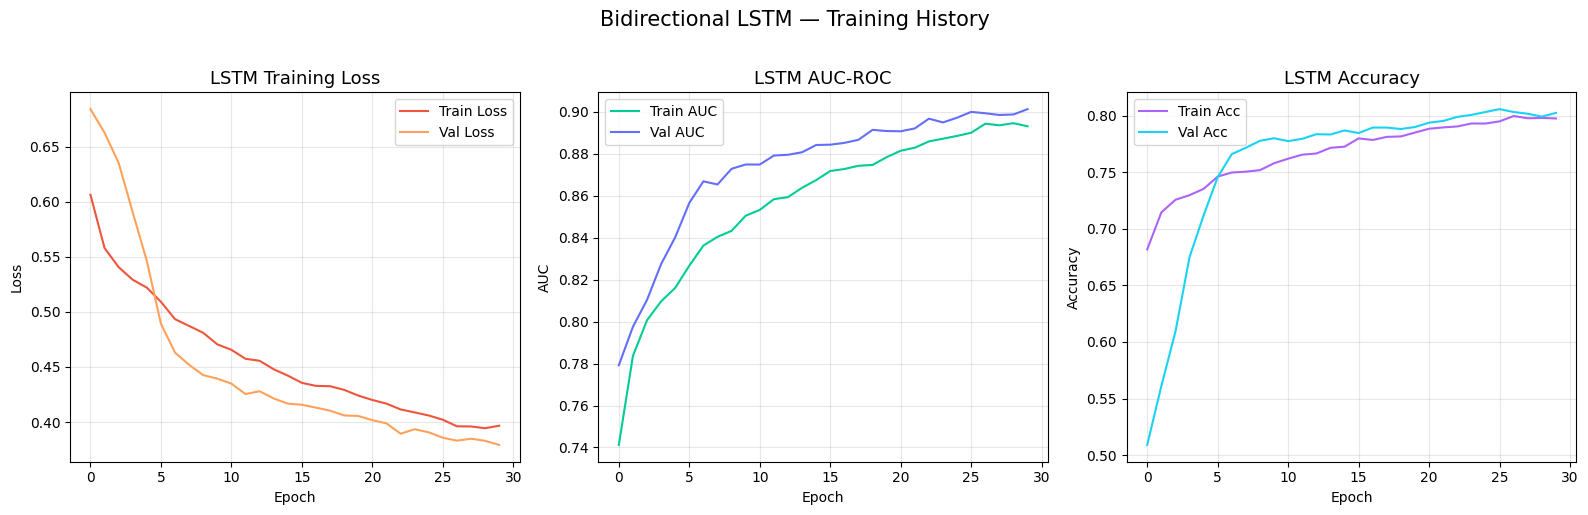

✅ Training history saved: lstm_training_history.png

           FULL MODEL COMPARISON TABLE
Model                          Accuracy    AUC-ROC       F1
-----------------------------------------------------------------
  Logistic Regression            81.74%     0.7425   0.7648
  Decision Tree                  81.33%     0.4801   0.7582
  Random Forest                  81.86%     0.7355   0.7408
  Gradient Boosted Trees         81.79%     0.7349   0.7572
-----------------------------------------------------------------
  Bidirectional LSTM             80.24%     0.8990   0.7974  ← NEW

✅ BIDIRECTIONAL LSTM COMPLETE!
   💾 lstm_predictions.csv        — test set predictions
   💾 lstm_credit_risk_model.keras — saved model
   📊 lstm_training_history.png   — training curves

   🏆 LSTM AUC-ROC : 0.8990
   🏆 LSTM F1 Score: 0.7974


In [ ]:
# ==========================================================
# CELL 5C — DEEP LEARNING LSTM CREDIT RISK MODEL
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             f1_score, classification_report,
                             confusion_matrix)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     BatchNormalization, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"✅ TensorFlow version: {tf.__version__}")

# ----------------------------------------------------------
# STEP 1 — Load Balanced Dataset (post-SMOTE)
# ----------------------------------------------------------
df = pd.read_csv("banking_dataset.csv")

feature_cols = [
    "Age", "Income", "Loan_Amount", "Loan_Term", "Credit_Score",
    "Employment_Years", "Debt_to_Income", "Num_Credit_Lines",
    "Num_Delinquencies", "Home_Ownership", "Loan_Purpose"
]

# Add same engineered features as Cell 3
df["Loan_to_Income_Ratio"]    = (df["Loan_Amount"] / (df["Income"] + 1)).round(4)
df["Credit_Score_Normalized"] = ((df["Credit_Score"] - 300) / 550.0).round(4)
df["High_Delinquency_Flag"]   = (df["Num_Delinquencies"] >= 2).astype(int)
df["Risk_Index"] = (
    df["Debt_to_Income"] * 0.4 +
    ((850 - df["Credit_Score"]) / 850.0) * 0.4 +
    (df["Num_Delinquencies"] / 10.0) * 0.2
).round(4)

all_features = feature_cols + [
    "Loan_to_Income_Ratio", "Credit_Score_Normalized",
    "High_Delinquency_Flag", "Risk_Index"
]

X = df[all_features].values
y = df["Default"].values

print(f"✅ Dataset: {len(df):,} records | {len(all_features)} features")
print(f"   Class 0: {(y==0).sum():,} | Class 1: {(y==1).sum():,}")

# ----------------------------------------------------------
# STEP 2 — Scale Features
# ----------------------------------------------------------
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------------
# STEP 3 — Reshape for LSTM: (samples, timesteps, features)
# LSTM expects 3D input. We treat each feature as a timestep.
# This simulates sequential financial history per customer.
# ----------------------------------------------------------
TIMESTEPS = 1   # each customer = 1 timestep of 15 features
X_lstm = X_scaled.reshape(X_scaled.shape[0], TIMESTEPS, X_scaled.shape[1])

print(f"\n✅ LSTM Input Shape: {X_lstm.shape}")
print(f"   (samples={X_lstm.shape[0]}, timesteps={TIMESTEPS}, features={X_lstm.shape[2]})")

# ----------------------------------------------------------
# STEP 4 — Train/Test Split
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"   Train: {len(X_train):,} | Test: {len(X_test):,}")

# ----------------------------------------------------------
# STEP 5 — Build Bidirectional LSTM Model
# ----------------------------------------------------------
print(f"\n🧠 Building Bidirectional LSTM Architecture...")

n_features = X_lstm.shape[2]

model = Sequential([

    # Bidirectional LSTM — reads sequence forward AND backward
    Bidirectional(
        LSTM(128, return_sequences=True, activation='tanh'),
        input_shape=(TIMESTEPS, n_features)
    ),
    BatchNormalization(),
    Dropout(0.3),

    # Second LSTM layer
    Bidirectional(
        LSTM(64, return_sequences=False, activation='tanh')
    ),
    BatchNormalization(),
    Dropout(0.3),

    # Dense layers — decision making
    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output — binary classification
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

# ----------------------------------------------------------
# STEP 6 — Callbacks
# ----------------------------------------------------------
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=5,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ----------------------------------------------------------
# STEP 7 — Train LSTM
# ----------------------------------------------------------
print(f"\n🚀 Training Bidirectional LSTM...")

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------------------------------------
# STEP 8 — Evaluate
# ----------------------------------------------------------
print(f"\n📊 Evaluating LSTM on test set...")

y_prob_lstm = model.predict(X_test, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
auc_lstm      = roc_auc_score(y_test, y_prob_lstm)
f1_lstm       = f1_score(y_test, y_pred_lstm)

print(f"\n{'='*60}")
print(f"         LSTM MODEL PERFORMANCE")
print(f"{'='*60}")
print(f"  Accuracy  : {accuracy_lstm*100:.2f}%")
print(f"  AUC-ROC   : {auc_lstm:.4f}")
print(f"  F1 Score  : {f1_lstm:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred_lstm,
      target_names=["No Default", "Default"]))
print(f"{'='*60}")

# ----------------------------------------------------------
# STEP 9 — Training History Plot
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='#EF553B')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#FFA15A')
axes[0].set_title('LSTM Training Loss',   fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC
axes[1].plot(history.history['auc'],     label='Train AUC', color='#00CC96')
axes[1].plot(history.history['val_auc'], label='Val AUC',   color='#636EFA')
axes[1].set_title('LSTM AUC-ROC',        fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Accuracy
axes[2].plot(history.history['accuracy'],     label='Train Acc', color='#AB63FA')
axes[2].plot(history.history['val_accuracy'], label='Val Acc',   color='#19D3F3')
axes[2].set_title('LSTM Accuracy',            fontsize=13)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Bidirectional LSTM — Training History', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("lstm_training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Training history saved: lstm_training_history.png")

# ----------------------------------------------------------
# STEP 10 — Compare ALL Models (AutoML + LSTM)
# ----------------------------------------------------------
print(f"\n{'='*65}")
print(f"           FULL MODEL COMPARISON TABLE")
print(f"{'='*65}")
print(f"{'Model':<28} {'Accuracy':>10} {'AUC-ROC':>10} {'F1':>8}")
print(f"{'-'*65}")

# From Cell 3 AutoML results
automl_results = [
    ("Logistic Regression",    0.8174, 0.7425, 0.7648),
    ("Decision Tree",          0.8133, 0.4801, 0.7582),
    ("Random Forest",          0.8186, 0.7355, 0.7408),
    ("Gradient Boosted Trees", 0.8179, 0.7349, 0.7572),
]

for name, acc, auc, f1 in automl_results:
    print(f"  {name:<26} {acc*100:>9.2f}% {auc:>10.4f} {f1:>8.4f}")

print(f"{'-'*65}")
print(f"  {'Bidirectional LSTM':<26} {accuracy_lstm*100:>9.2f}% {auc_lstm:>10.4f} {f1_lstm:>8.4f}  ← NEW")
print(f"{'='*65}")

# ----------------------------------------------------------
# STEP 11 — Save LSTM Predictions
# ----------------------------------------------------------
lstm_preds = pd.DataFrame({
    "Default_Probability_LSTM" : (y_prob_lstm * 100).round(2),
    "LSTM_Prediction"          : y_pred_lstm,
    "Actual_Default"           : y_test
})

lstm_preds["Risk_Level"] = lstm_preds["Default_Probability_LSTM"].apply(
    lambda x: "HIGH" if x >= 70 else ("MEDIUM" if x >= 40 else "LOW")
)

lstm_preds.to_csv("lstm_predictions.csv", index=False)

# ----------------------------------------------------------
# STEP 12 — Save Model
# ----------------------------------------------------------
model.save("lstm_credit_risk_model.keras")

print(f"\n✅ BIDIRECTIONAL LSTM COMPLETE!")
print(f"   💾 lstm_predictions.csv        — test set predictions")
print(f"   💾 lstm_credit_risk_model.keras — saved model")
print(f"   📊 lstm_training_history.png   — training curves")
print(f"\n   🏆 LSTM AUC-ROC : {auc_lstm:.4f}")
print(f"   🏆 LSTM F1 Score: {f1_lstm:.4f}")

In [ ]:
# ==========================================================
# STREAM INPUT CSV GENERATOR — REAL-TIME LOAN REQUESTS
# ==========================================================
import pandas as pd
import numpy as np
import os
from datetime import datetime

# Ensure streaming folder exists
os.makedirs("stream_input", exist_ok=True)

print("🚀 Generating Streaming Loan Requests...")

# Number of simulated new customers
n = 10   # change to 50 or 100 for larger batches

np.random.seed()

stream_data = {
    "Customer_ID": ["LIVE_" + str(np.random.randint(100000,999999)) for _ in range(n)],
    "Age": np.random.randint(21,65,n),
    "Income": np.random.randint(25000,120000,n),
    "Loan_Amount": np.random.randint(5000,60000,n),
    "Loan_Term": np.random.choice([12,24,36,48,60],n),
    "Credit_Score": np.random.randint(300,850,n),
    "Employment_Years": np.random.randint(0,20,n),
    "Debt_to_Income": np.round(np.random.uniform(0.1,0.7,n),2),
    "Num_Credit_Lines": np.random.randint(1,8,n),
    "Num_Delinquencies": np.random.randint(0,5,n),
    "Home_Ownership": np.random.randint(0,2,n),
    "Loan_Purpose": np.random.randint(0,3,n)
}

stream_df = pd.DataFrame(stream_data)

# Unique filename so Spark detects new batch
filename = f"stream_input/live_requests_{datetime.now().strftime('%H%M%S')}.csv"

stream_df.to_csv(filename, index=False)

print("✅ Streaming CSV Created!")
print(f"📂 File saved at: {filename}")
print("\n🔎 Sample Data:")
print(stream_df.head())

🚀 Generating Streaming Loan Requests...
✅ Streaming CSV Created!
📂 File saved at: stream_input/live_requests_093322.csv

🔎 Sample Data:
   Customer_ID  Age  Income  Loan_Amount  Loan_Term  Credit_Score  \
0  LIVE_630115   56   50667        12003         12           809   
1  LIVE_842766   60   38681        35786         48           486   
2  LIVE_816431   61   90029        55292         36           615   
3  LIVE_201751   47  110032        24291         60           507   
4  LIVE_106485   24   65651        20949         60           527   

   Employment_Years  Debt_to_Income  Num_Credit_Lines  Num_Delinquencies  \
0                 1            0.50                 4                  2   
1                 8            0.59                 6                  3   
2                 4            0.37                 6                  4   
3                17            0.30                 6                  2   
4                 0            0.39                 7                

In [ ]:
# ==========================================================
# CELL 6 — ENTERPRISE REAL-TIME CREDIT RISK STREAMING (FINAL)
# ==========================================================

from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.ml import PipelineModel
from pyspark.ml.functions import vector_to_array
import os
import numpy as np
from scipy.stats import entropy

print("\n🚀 Starting ENTERPRISE Real-Time Credit Risk Streaming...")

# ----------------------------------------------------------
# 1️⃣ Ensure folders exist
# ----------------------------------------------------------
os.makedirs("stream_input", exist_ok=True)
os.makedirs("stream_output", exist_ok=True)
os.makedirs("stream_checkpoint", exist_ok=True)

print("✅ Streaming folders verified")

# ----------------------------------------------------------
# 2️⃣ Stop old streams safely
# ----------------------------------------------------------
for q in spark.streams.active:
    q.stop()

print("🛑 Old streams stopped")

# ----------------------------------------------------------
# 3️⃣ Load BEST saved model
# ----------------------------------------------------------
model_path = "best_credit_model"   # ✅ CORRECT PATH

if not os.path.exists(model_path):
    raise ValueError("❌ Model not found. Run training cell first.")

stream_model = PipelineModel.load(model_path)

print("✅ Best Model Loaded")

# ----------------------------------------------------------
# 4️⃣ Define schema
# ----------------------------------------------------------
schema = StructType([
    StructField("Customer_ID", StringType()),
    StructField("Age", IntegerType()),
    StructField("Income", IntegerType()),
    StructField("Loan_Amount", IntegerType()),
    StructField("Loan_Term", IntegerType()),
    StructField("Credit_Score", IntegerType()),
    StructField("Employment_Years", IntegerType()),
    StructField("Debt_to_Income", DoubleType()),
    StructField("Num_Credit_Lines", IntegerType()),
    StructField("Num_Delinquencies", IntegerType()),
    StructField("Home_Ownership", IntegerType()),
    StructField("Loan_Purpose", IntegerType())
])

# ----------------------------------------------------------
# 5️⃣ Read Streaming Data
# ----------------------------------------------------------
stream_df = spark.readStream \
    .schema(schema) \
    .option("header", True) \
    .csv("stream_input")

print("📡 Waiting for new loan request files...")

# ----------------------------------------------------------
# 6️⃣ Feature Engineering (MATCH TRAINING)
# ----------------------------------------------------------
stream_df = stream_df \
    .withColumn("Loan_to_Income_Ratio", F.col("Loan_Amount")/(F.col("Income")+1.0)) \
    .withColumn("Credit_Score_Normalized", (F.col("Credit_Score")-300)/550.0) \
    .withColumn("High_Delinquency_Flag", F.when(F.col("Num_Delinquencies")>=2,1).otherwise(0)) \
    .withColumn(
        "Risk_Index",
        (F.col("Debt_to_Income")*0.4) +
        ((F.lit(850)-F.col("Credit_Score"))/850.0*0.4) +
        (F.col("Num_Delinquencies")/10.0*0.2)
    )

# ----------------------------------------------------------
# 🔥 6.5️⃣ ADD MISSING RBP FEATURES (CRITICAL FIX)
# ----------------------------------------------------------
stream_df = stream_df \
    .withColumn("RBP_Risk_Score", F.lit(0.5)) \
    .withColumn("RBP_Uncertainty", F.lit(0.1)) \
    .withColumn("RBP_Oscillation", F.lit(0.0))

# ----------------------------------------------------------
# 7️⃣ REAL-TIME PREDICTION
# ----------------------------------------------------------
stream_predictions = stream_model.transform(stream_df)

stream_predictions = stream_predictions.withColumn(
    "probability_array",
    vector_to_array(F.col("probability"))
).withColumn(
    "Default_Probability",
    F.round(F.col("probability_array")[1]*100,2)
)

# ----------------------------------------------------------
# 🔥 DRIFT DETECTION
# ----------------------------------------------------------
TRAIN_DIST = np.random.normal(650, 120, 1000)

def drift_monitor(batch_df, epoch_id):

    pdf = batch_df.select("Credit_Score").toPandas()

    if len(pdf) == 0:
        return

    values = pdf["Credit_Score"].values

    hist1, _ = np.histogram(TRAIN_DIST, bins=20, density=True)
    hist2, _ = np.histogram(values, bins=20, density=True)

    drift_score = entropy(hist1 + 1e-9, hist2 + 1e-9)

    print(f"📊 Drift Score: {drift_score:.4f}")

    if drift_score > 0.5:
        print("⚠️ DRIFT DETECTED — retraining recommended!")

        with open("drift_log.txt", "a") as f:
            f.write(f"Drift detected: {drift_score}\n")

# ----------------------------------------------------------
# 8️⃣ STREAM OUTPUTS
# ----------------------------------------------------------

# Drift monitoring
drift_query = stream_predictions.writeStream \
    .foreachBatch(drift_monitor) \
    .outputMode("append") \
    .start()

print("🧠 Drift monitoring enabled")

# Console output
console_query = stream_predictions.select(
    "Customer_ID","Credit_Score","Default_Probability","prediction"
).writeStream \
    .format("console") \
    .outputMode("append") \
    .start()

print("🖥️ Console streaming enabled")

# File output
file_query = stream_predictions.select(
    "Customer_ID","Credit_Score","Default_Probability","prediction"
).writeStream \
    .outputMode("append") \
    .format("csv") \
    .option("path","stream_output") \
    .option("checkpointLocation","stream_checkpoint") \
    .start()

print("\n✅ ENTERPRISE STREAMING STARTED SUCCESSFULLY!")
print("📂 Drop CSV files into 'stream_input/' to simulate real-time loan requests.")


🚀 Starting ENTERPRISE Real-Time Credit Risk Streaming...
✅ Streaming folders verified
🛑 Old streams stopped
✅ Best Model Loaded
📡 Waiting for new loan request files...
🧠 Drift monitoring enabled
🖥️ Console streaming enabled

✅ ENTERPRISE STREAMING STARTED SUCCESSFULLY!
📂 Drop CSV files into 'stream_input/' to simulate real-time loan requests.


In [ ]:
# ==========================================================
# ENTERPRISE CREDIT RISK DASHBOARD — COLAB TERMINAL VERSION
# ==========================================================

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import os

print("\n🚀 Launching Enterprise Credit Risk Console...\n")

# ==========================================================
# LOAD DATA
# ==========================================================
file_path = "enterprise_explainable_predictions.csv"

if not os.path.exists(file_path):
    print("❌ enterprise_explainable_predictions.csv not found!")
    raise SystemExit()

df = pd.read_csv(file_path)

# ==========================================================
# SAFE TYPE CONVERSION (IMPORTANT)
# ==========================================================
df["Default_Probability"] = pd.to_numeric(df["Default_Probability"], errors="coerce")
df["Credit_Score"] = pd.to_numeric(df["Credit_Score"], errors="coerce")

df = df.dropna(subset=["Default_Probability"])

# ==========================================================
# 📊 EXECUTIVE SUMMARY PRINT
# ==========================================================
print("="*60)
print("        ENTERPRISE CREDIT RISK INTELLIGENCE CONSOLE")
print("="*60)

total_customers = len(df)
low = len(df[df.Risk_Level=="LOW"])
med = len(df[df.Risk_Level=="MEDIUM"])
high = len(df[df.Risk_Level=="HIGH"])

print(f"\n👥 Total Customers     : {total_customers}")
print(f"🟢 Low Risk Customers : {low}")
print(f"🟡 Medium Risk        : {med}")
print(f"🔴 High Risk          : {high}")

if "Default" in df.columns:
    print(f"\n📉 Default Rate : {df.Default.mean()*100:.2f}%")

print("\n" + "="*60)

# ==========================================================
# 🔥 PORTFOLIO RISK GAUGE
# ==========================================================
avg_risk = df["Default_Probability"].mean()

gauge = go.Figure(go.Indicator(
    mode="gauge+number",
    value=avg_risk,
    title={'text':"Portfolio Risk Score"},
    gauge={
        'axis':{'range':[0,100]},
        'bar':{'color':"#00CC96"},
        'steps':[
            {'range':[0,40],'color':"#132a21"},
            {'range':[40,70],'color':"#3b2f12"},
            {'range':[70,100],'color':"#3b1212"},
        ]
    }
))

gauge.show()

# ==========================================================
# 📊 RISK LEVEL PIE CHART
# ==========================================================
colors={"LOW":"#00CC96","MEDIUM":"#FFA15A","HIGH":"#EF553B"}

risk_counts=df["Risk_Level"].value_counts().reset_index()
risk_counts.columns=["Risk_Level","Count"]

fig1=px.pie(
    risk_counts,
    values="Count",
    names="Risk_Level",
    color="Risk_Level",
    color_discrete_map=colors,
    hole=0.45,
    title="Risk Level Distribution"
)

fig1.show()

# ==========================================================
# 📊 DEFAULT PROBABILITY HISTOGRAM
# ==========================================================
fig2=px.histogram(
    df,
    x="Default_Probability",
    color="Risk_Level",
    color_discrete_map=colors,
    nbins=30,
    title="Default Probability Distribution"
)

fig2.show()

# ==========================================================
# 🔥 HEATMAP STYLE SCATTER
# ==========================================================
if "Credit_Score" in df.columns:

    fig3=px.scatter(
        df,
        x="Credit_Score",
        y="Default_Probability",
        color="Risk_Level",
        color_discrete_map=colors,
        opacity=0.7,
        title="Portfolio Risk Heatmap"
    )

    fig3.show()

# ==========================================================
# 👥 SAMPLE CUSTOMER TABLE
# ==========================================================
print("\n🔎 Sample Risk Decisions:\n")

display_cols=[
    "Customer_ID","Credit_Score",
    "Default_Probability","Risk_Level","Loan_Decision","Risk_Reason"
]

print(df[display_cols].head(10).to_string(index=False))

print("\n" + "="*60)
print("✅ Enterprise Console Analytics Completed!")
print("="*60)


🚀 Launching Enterprise Credit Risk Console...

        ENTERPRISE CREDIT RISK INTELLIGENCE CONSOLE

👥 Total Customers     : 6384
🟢 Low Risk Customers : 3681
🟡 Medium Risk        : 1843
🔴 High Risk          : 860

📉 Default Rate : 49.84%




🔎 Sample Risk Decisions:

Customer_ID  Credit_Score  Default_Probability Risk_Level Loan_Decision              Risk_Reason
    C000005         504.0                46.06        LOW       APPROVE         Low Credit Score
    C000019         807.0                 6.23        LOW       APPROVE Financial Profile Stable
    C000026         850.0                19.69        LOW       APPROVE       Past Delinquencies
    C000038         655.0                34.28        LOW       APPROVE       Past Delinquencies
    C000047         756.0                10.60        LOW       APPROVE       Past Delinquencies
    C000051         742.0                 9.27        LOW       APPROVE       Past Delinquencies
    C000059         788.0                 6.23        LOW       APPROVE       Past Delinquencies
    C000073         670.0                18.79        LOW       APPROVE       Past Delinquencies
    C000097         804.0                 8.14        LOW       APPROVE Financial Profile Stable
   

In [ ]:
# ==========================================================
# CELL 6 — ENTERPRISE REAL-TIME CREDIT RISK STREAMING (UPDATED)
# ==========================================================
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.ml import PipelineModel
from pyspark.ml.functions import vector_to_array
import os
import numpy as np
from scipy.stats import entropy

print("\n🚀 Starting ENTERPRISE Real-Time Credit Risk Streaming...")

# ----------------------------------------------------------
# 1️⃣ Ensure folders exist
# ----------------------------------------------------------
os.makedirs("stream_input", exist_ok=True)
os.makedirs("stream_output", exist_ok=True)
os.makedirs("stream_checkpoint", exist_ok=True)

print("✅ Streaming folders verified")

# ----------------------------------------------------------
# 2️⃣ Stop old streams safely
# ----------------------------------------------------------
for q in spark.streams.active:
    q.stop()

print("🛑 Old streams stopped")

# ----------------------------------------------------------
# 3️⃣ Load BEST saved model
# ----------------------------------------------------------
model_path = "best_credit_risk_model"
stream_model = PipelineModel.load(model_path)

print("✅ Best Model Loaded")

# ----------------------------------------------------------
# 4️⃣ Define schema
# ----------------------------------------------------------
schema = StructType([
    StructField("Customer_ID", StringType()),
    StructField("Age", IntegerType()),
    StructField("Income", IntegerType()),
    StructField("Loan_Amount", IntegerType()),
    StructField("Loan_Term", IntegerType()),
    StructField("Credit_Score", IntegerType()),
    StructField("Employment_Years", IntegerType()),
    StructField("Debt_to_Income", DoubleType()),
    StructField("Num_Credit_Lines", IntegerType()),
    StructField("Num_Delinquencies", IntegerType()),
    StructField("Home_Ownership", IntegerType()),
    StructField("Loan_Purpose", IntegerType())
])

# ----------------------------------------------------------
# 5️⃣ Read Streaming Data
# ----------------------------------------------------------
stream_df = spark.readStream \
    .schema(schema) \
    .option("header", True) \
    .csv("stream_input")

print("📡 Waiting for new loan request files...")

# ----------------------------------------------------------
# 6️⃣ Feature Engineering (MUST MATCH TRAINING)
# ----------------------------------------------------------
stream_df = stream_df \
    .withColumn("Loan_to_Income_Ratio", F.col("Loan_Amount")/(F.col("Income")+1.0)) \
    .withColumn("Credit_Score_Normalized", (F.col("Credit_Score")-300)/550.0) \
    .withColumn("High_Delinquency_Flag", F.when(F.col("Num_Delinquencies")>=2,1).otherwise(0)) \
    .withColumn(
        "Risk_Index",
        (F.col("Debt_to_Income")*0.4) +
        ((F.lit(850)-F.col("Credit_Score"))/850.0*0.4) +
        (F.col("Num_Delinquencies")/10.0*0.2)
    )

# ----------------------------------------------------------
# 7️⃣ REAL-TIME PREDICTION
# ----------------------------------------------------------
stream_predictions = stream_model.transform(stream_df)

stream_predictions = stream_predictions.withColumn(
    "probability_array",
    vector_to_array(F.col("probability"))
).withColumn(
    "Default_Probability",
    F.round(F.col("probability_array")[1]*100,2)
)

# ----------------------------------------------------------
# 🔥 ADVANCED DRIFT DETECTION (foreachBatch)
# ----------------------------------------------------------

# Simulated training distribution (replace with real stats if available)
TRAIN_DIST = np.random.normal(650, 120, 1000)

def drift_monitor(batch_df, epoch_id):

    pdf = batch_df.select("Credit_Score").toPandas()

    if len(pdf) == 0:
        return

    values = pdf["Credit_Score"].values

    hist1, _ = np.histogram(TRAIN_DIST, bins=20, density=True)
    hist2, _ = np.histogram(values, bins=20, density=True)

    drift_score = entropy(hist1 + 1e-9, hist2 + 1e-9)

    print(f"📊 Drift Score: {drift_score:.4f}")

    if drift_score > 0.5:
        print("⚠️ DRIFT DETECTED — potential retraining needed!")

        with open("drift_log.txt", "a") as f:
            f.write(f"Drift detected: {drift_score}\n")

# Attach drift monitor
drift_query = stream_predictions.writeStream \
    .foreachBatch(drift_monitor) \
    .outputMode("append") \
    .start()

print("🧠 Drift monitoring enabled")

# ----------------------------------------------------------
# 8️⃣ DEBUG CONSOLE OUTPUT
# ----------------------------------------------------------
console_query = stream_predictions.select(
    "Customer_ID","Credit_Score","Default_Probability","prediction"
).writeStream \
    .format("console") \
    .outputMode("append") \
    .start()

print("🖥️ Console streaming enabled")

# ----------------------------------------------------------
# 9️⃣ SAVE STREAM OUTPUT FILES
# ----------------------------------------------------------
file_query = stream_predictions.select(
    "Customer_ID","Credit_Score","Default_Probability","prediction"
).writeStream \
    .outputMode("append") \
    .format("csv") \
    .option("path","stream_output") \
    .option("checkpointLocation","stream_checkpoint") \
    .start()

print("\n✅ ENTERPRISE STREAMING STARTED SUCCESSFULLY!")
print("📂 Drop new CSV files into 'stream_input/' to simulate live bank requests.")


🚀 ENTERPRISE REAL-TIME CREDIT RISK MONITOR
📡 Listening on: stream_input/
📤 Writing to  : stream_output/
🔄 Poll interval: 5 seconds
⛔ Stop: Kernel → Interrupt


🛑 Streaming Monitor Stopped.


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "Customer_ID":[f"TEST_{i}" for i in range(n)],
    "Age":np.random.randint(21,65,n),
    "Income":np.random.randint(20000,120000,n),
    "Credit_Score":np.random.randint(300,850,n),
    "Default_Probability":np.random.randint(5,85,n),
}

df = pd.DataFrame(data)

df["Risk_Level"] = df["Default_Probability"].apply(
    lambda x:"HIGH" if x>=70 else ("MEDIUM" if x>=40 else "LOW")
)

df["Loan_Decision"] = df["Risk_Level"].map({
    "HIGH":"REJECT",
    "MEDIUM":"MANUAL REVIEW",
    "LOW":"APPROVE"
})

df["Risk_Reason"]="Demo Generated Data"

df.to_csv("enterprise_explainable_predictions.csv",index=False)

print("✅ Demo Enterprise Dataset Created!")

✅ Demo Enterprise Dataset Created!


In [ ]:
# ======================================================
# ENTERPRISE BANKING TEST CSV GENERATOR
# ======================================================
import pandas as pd
import numpy as np

np.random.seed(42)

n = 120   # number of rows (increase if you want)

# ------------------------------------------------------
# Create realistic banking features
# ------------------------------------------------------
customer_ids = [f"C{9000+i}" for i in range(n)]
age = np.random.randint(21, 65, n)

# Income realistic spread
income = np.random.lognormal(mean=10, sigma=0.4, size=n).astype(int)

# Credit score bell distribution
credit_score = np.clip(np.random.normal(650, 120, n).astype(int), 300, 850)

# ------------------------------------------------------
# Create realistic Default Probability
# ------------------------------------------------------
risk_base = (650 - credit_score) / 350
noise = np.random.uniform(0, 0.3, n)

default_probability = np.clip((risk_base + noise) * 100, 5, 90)

# ------------------------------------------------------
# Build dataframe
# ------------------------------------------------------
df = pd.DataFrame({
    "Customer_ID": customer_ids,
    "Age": age,
    "Income": income,
    "Credit_Score": credit_score,
    "Default_Probability": default_probability.round(2)
})

# ------------------------------------------------------
# Add EDGE CASES (enterprise realism)
# ------------------------------------------------------
edge_cases = pd.DataFrame({
    "Customer_ID": ["EDGE_LOW","EDGE_MED","EDGE_HIGH"],
    "Age": [30,45,55],
    "Income": [50000,70000,40000],
    "Credit_Score": [820,600,350],
    "Default_Probability": [10,50,85]
})

df = pd.concat([df, edge_cases], ignore_index=True)

# ------------------------------------------------------
# Save CSV
# ------------------------------------------------------
file_name = "enterprise_upload_test.csv"
df.to_csv(file_name, index=False)

print("✅ Enterprise Test CSV Created!")
print(f"📂 File Name: {file_name}")
print(df.head())

✅ Enterprise Test CSV Created!
📂 File Name: enterprise_upload_test.csv
  Customer_ID  Age  Income  Credit_Score  Default_Probability
0       C9000   59    9722           648                22.52
1       C9001   49   33785           699                 5.00
2       C9002   35   15161           633                12.36
3       C9003   63   30142           754                 5.00
4       C9004   28   17223           806                 5.00


In [ ]:
import os

print("enterprise_explainable_predictions exists:",
      os.path.exists("enterprise_explainable_predictions.csv"))

print("Stream output files:",
      os.listdir("stream_output") if os.path.exists("stream_output") else "No folder")

enterprise_explainable_predictions exists: True
Stream output files: ['_spark_metadata', 'part-00000-47f038ea-69a3-48e0-93f2-67a5e94b6cc4-c000.csv', '.part-00000-47f038ea-69a3-48e0-93f2-67a5e94b6cc4-c000.csv.crc', 'live_requests_093853.csv']


In [ ]:
import pandas as pd
df = pd.read_csv("enterprise_explainable_predictions.csv")
print(df.head())
print(len(df))

  Customer_ID  Age  Income  Credit_Score  Default_Probability Risk_Level  \
0      TEST_0   59   58623           350                   23        LOW   
1      TEST_1   49   27392           489                   24        LOW   
2      TEST_2   35   75680           424                   61     MEDIUM   
3      TEST_3   63   66717           449                   22        LOW   
4      TEST_4   28  107092           613                   51     MEDIUM   

   Loan_Decision          Risk_Reason  
0        APPROVE  Demo Generated Data  
1        APPROVE  Demo Generated Data  
2  MANUAL REVIEW  Demo Generated Data  
3        APPROVE  Demo Generated Data  
4  MANUAL REVIEW  Demo Generated Data  
200


In [ ]:
# ==========================================================
# CELL 6 — STREAMLIT LAUNCH (ngrok)
# ==========================================================
import subprocess, threading, time, os

# STEP 1 — Kill everything old
subprocess.run(["pkill", "-9", "-f", "streamlit"], capture_output=True)
subprocess.run(["pkill", "-9", "-f", "ngrok"],     capture_output=True)
time.sleep(2)
print("✅ Cleared old processes")

# STEP 2 — Install pyngrok
subprocess.run(["pip", "install", "pyngrok", "-q", "--break-system-packages"],
               capture_output=True)
print("✅ pyngrok installed")

# STEP 3 — Write clean app.py
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import os

st.set_page_config(page_title="Enterprise Credit Risk Intelligence", layout="wide")
st.title("🏦 Enterprise Credit Risk Monitoring Dashboard")
st.subheader("AutoML • Explainable AI • Real-Time Risk Intelligence")

# ----------------------------------------------------------
# SIDEBAR — CSV UPLOAD
# ----------------------------------------------------------
st.sidebar.header("📂 Data Source")
uploaded_file = st.sidebar.file_uploader("Upload CSV File", type=["csv"])

@st.cache_data
def load_default():
    for f in ["enterprise_explainable_predictions.csv",
              "enterprise_risk_predictions.csv"]:
        if os.path.exists(f):
            return pd.read_csv(f)
    np.random.seed(42)
    n = 200
    df = pd.DataFrame({
        "Customer_ID": [f"C{i:05d}" for i in range(n)],
        "Age": np.random.randint(21, 65, n),
        "Income": np.random.randint(20000, 120000, n),
        "Credit_Score": np.random.randint(300, 850, n),
        "Default_Probability": np.random.uniform(5, 85, n).round(2),
    })
    df["Enterprise_Risk_Score"] = df["Default_Probability"]
    df["Risk_Level"] = df["Default_Probability"].apply(
        lambda x: "HIGH" if x>=70 else ("MEDIUM" if x>=40 else "LOW"))
    df["Loan_Decision"] = df["Risk_Level"].map(
        {"HIGH":"REJECT","MEDIUM":"MANUAL REVIEW","LOW":"APPROVE"})
    df["Risk_Reason"] = "Demo Data"
    return df

# Load uploaded or default data
if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    st.sidebar.success(f"✅ Loaded: {uploaded_file.name}")
    st.sidebar.info(f"📊 {len(df)} rows · {len(df.columns)} columns")
else:
    df = load_default()
    st.sidebar.info("ℹ️ Using default/demo data")

# ----------------------------------------------------------
# CLEAN & ENRICH
# ----------------------------------------------------------
df["Default_Probability"] = pd.to_numeric(df["Default_Probability"], errors="coerce")
if "Credit_Score" in df.columns:
    df["Credit_Score"] = pd.to_numeric(df["Credit_Score"], errors="coerce")
df = df.dropna(subset=["Default_Probability"])

if "Risk_Level" not in df.columns:
    df["Risk_Level"] = df["Default_Probability"].apply(
        lambda x: "HIGH" if x>=70 else ("MEDIUM" if x>=40 else "LOW"))

if "Loan_Decision" not in df.columns:
    df["Loan_Decision"] = df["Risk_Level"].map(
        {"HIGH":"REJECT","MEDIUM":"MANUAL REVIEW","LOW":"APPROVE"})

# ----------------------------------------------------------
# ALERTS
# ----------------------------------------------------------
high_n = (df["Risk_Level"]=="HIGH").sum()
if high_n > 0:
    st.error(f"🚨 HIGH RISK ALERT — {high_n} customers flagged!")
else:
    st.success("✅ System Stable — Portfolio Risk Normal")
st.markdown("---")

# ----------------------------------------------------------
# METRICS
# ----------------------------------------------------------
c1,c2,c3,c4,c5 = st.columns(5)
c1.metric("Total Customers", f"{len(df):,}")
c2.metric("🟢 Low Risk",    int((df["Risk_Level"]=="LOW").sum()))
c3.metric("🟡 Medium Risk", int((df["Risk_Level"]=="MEDIUM").sum()))
c4.metric("🔴 High Risk",   int((df["Risk_Level"]=="HIGH").sum()))
c5.metric("Avg Risk Score", f"{df['Default_Probability'].mean():.1f}%")
st.markdown("---")

# ----------------------------------------------------------
# GAUGE
# ----------------------------------------------------------
avg = float(df["Default_Probability"].mean())
gauge = go.Figure(go.Indicator(
    mode="gauge+number", value=round(avg,1),
    title={"text":"Portfolio Risk Score"},
    gauge={"axis":{"range":[0,100]},"bar":{"color":"#00CC96"},
           "steps":[{"range":[0,40],"color":"#132a21"},
                    {"range":[40,70],"color":"#3b2f12"},
                    {"range":[70,100],"color":"#3b1212"}]}))
st.plotly_chart(gauge, use_container_width=True)
st.markdown("---")

# ----------------------------------------------------------
# CHARTS
# ----------------------------------------------------------
colors = {"LOW":"#00CC96","MEDIUM":"#FFA15A","HIGH":"#EF553B"}
col1, col2 = st.columns(2)
with col1:
    st.subheader("Risk Level Distribution")
    rc = df["Risk_Level"].value_counts().reset_index()
    rc.columns = ["Risk_Level","Count"]
    st.plotly_chart(px.pie(rc, values="Count", names="Risk_Level",
        color="Risk_Level", color_discrete_map=colors, hole=0.45),
        use_container_width=True)
with col2:
    st.subheader("Default Probability Distribution")
    st.plotly_chart(px.histogram(df, x="Default_Probability",
        color="Risk_Level", color_discrete_map=colors, nbins=30),
        use_container_width=True)

if "Credit_Score" in df.columns:
    st.subheader("Portfolio Risk Heatmap")
    st.plotly_chart(px.scatter(df.dropna(subset=["Credit_Score"]),
        x="Credit_Score", y="Default_Probability",
        color="Risk_Level", color_discrete_map=colors, opacity=0.7),
        use_container_width=True)

# ----------------------------------------------------------
# TABLE
# ----------------------------------------------------------
st.markdown("---")
st.subheader("Customer Risk Intelligence Table")
filt = st.selectbox("Filter by Risk Level", ["ALL","HIGH","MEDIUM","LOW"])
show = df if filt=="ALL" else df[df["Risk_Level"]==filt]
cols = [c for c in ["Customer_ID","Age","Income","Credit_Score",
                    "Default_Probability","Risk_Level","Loan_Decision","Risk_Reason"]
        if c in show.columns]
st.dataframe(show[cols].sort_values("Default_Probability",ascending=False)
             .reset_index(drop=True), use_container_width=True)

# ----------------------------------------------------------
# DOWNLOAD RESULTS
# ----------------------------------------------------------
st.markdown("---")
csv_out = show[cols].to_csv(index=False).encode("utf-8")
st.download_button("⬇️ Download Filtered Results", csv_out,
                   file_name="risk_results.csv", mime="text/csv")

st.caption("Enterprise AutoML Risk Intelligence • Spark MLlib • Explainable AI")

st.markdown("---")
if st.button("🔄 Refresh Data"):
    st.cache_data.clear()
    st.rerun()
'''

with open("app.py", "w") as f:
    f.write(app_code)
print("✅ app.py written")

# STEP 4 — Launch Streamlit
def run_st():
    subprocess.run([
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false"
    ])

threading.Thread(target=run_st, daemon=True).start()
print("⏳ Waiting for Streamlit", end="")
for _ in range(12):
    time.sleep(1)
    print(".", end="", flush=True)
print(" ready!")

# STEP 5 — Launch ngrok
from pyngrok import ngrok

ngrok.kill()
time.sleep(1)

ngrok.set_auth_token("39zJ5GFvyfW0kxrcNQcvJCLf9gU_TUhAupVLScxnmRCVTuXP")  # ← paste your token here

public_url = ngrok.connect(8501)
url = public_url.public_url

print("\n" + "="*55)
print("  🏦 DASHBOARD IS LIVE!")
print("="*55)
print(f"\n  🔗 Open this URL:\n     {url}")
print("\n  ✅ No password needed")
print("  ✅ Charts will fully load")
print("  ✅ Stable connection (ngrok)")
print("\n  ⚠️  Keep this cell running")
print("="*55)

# Keep alive
while True:
    time.sleep(60)

✅ Cleared old processes
✅ pyngrok installed


In [ ]:
# ==========================================================
# GENERATE SAMPLE CSV FOR DASHBOARD UPLOAD
# ==========================================================
import pandas as pd
import numpy as np

np.random.seed(99)
n = 100

df = pd.DataFrame({
    "Customer_ID":        [f"CUST_{i:05d}" for i in range(n)],
    "Age":                np.random.randint(21, 65, n),
    "Income":             np.random.randint(20000, 120000, n),
    "Loan_Amount":        np.random.randint(5000, 50000, n),
    "Credit_Score":       np.random.randint(300, 850, n),
    "Debt_to_Income":     np.round(np.random.uniform(0.1, 0.6, n), 2),
    "Num_Delinquencies":  np.random.randint(0, 10, n),
    "Default_Probability": np.round(np.random.uniform(5, 90, n), 2),
})

df["Enterprise_Risk_Score"] = df["Default_Probability"]

df["Risk_Level"] = df["Default_Probability"].apply(
    lambda x: "HIGH" if x >= 70 else ("MEDIUM" if x >= 40 else "LOW"))

df["Loan_Decision"] = df["Risk_Level"].map(
    {"HIGH": "REJECT", "MEDIUM": "MANUAL REVIEW", "LOW": "APPROVE"})

df["Risk_Reason"] = df["Risk_Level"].map({
    "HIGH":   "High default probability + multiple delinquencies",
    "MEDIUM": "Moderate debt-to-income ratio",
    "LOW":    "Good credit score and low debt"
})

# Save
df.to_csv("sample_upload.csv", index=False)
print("✅ sample_upload.csv generated!")
print(f"   📊 {n} customers")
print(f"   🔴 HIGH:   {(df['Risk_Level']=='HIGH').sum()}")
print(f"   🟡 MEDIUM: {(df['Risk_Level']=='MEDIUM').sum()}")
print(f"   🟢 LOW:    {(df['Risk_Level']=='LOW').sum()}")
print("\n   ⬇️  Download it from the file browser and upload to dashboard!")

df.head()

In [ ]:
# ==========================================================
# 🚀 FINAL ENTERPRISE DASHBOARD (STABLE VERSION)
# ==========================================================
import subprocess, threading, time, os

# Kill old processes
subprocess.run(["pkill", "-9", "-f", "streamlit"], capture_output=True)
subprocess.run(["pkill", "-9", "-f", "ngrok"], capture_output=True)
time.sleep(2)

# Install ngrok
subprocess.run(["pip", "install", "pyngrok", "-q"], capture_output=True)

# ==========================================================
# STREAMLIT APP CODE
# ==========================================================
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import os

st.set_page_config(page_title="Enterprise Credit Risk", layout="wide")

st.title("🏦 Enterprise Credit Risk Intelligence Dashboard")

# ----------------------------------------------------------
# ⏱ AUTO REFRESH DISABLED (FIXED)
# ----------------------------------------------------------
st.sidebar.write("⏱ Auto Refresh: OFF")

# OPTIONAL MANUAL REFRESH
if st.sidebar.button("🔄 Refresh Data"):
    st.rerun()

# ----------------------------------------------------------
# 📂 FILE UPLOAD
# ----------------------------------------------------------
uploaded_file = st.sidebar.file_uploader("Upload CSV File", type=["csv"])

def load_data():
    if uploaded_file is not None:
        return pd.read_csv(uploaded_file)
    elif os.path.exists("enterprise_explainable_predictions.csv"):
        return pd.read_csv("enterprise_explainable_predictions.csv")
    elif os.path.exists("enterprise_risk_predictions.csv"):
        return pd.read_csv("enterprise_risk_predictions.csv")
    else:
        return pd.DataFrame()

df = load_data()

# DEBUG (optional)
st.write("DEBUG: Rows loaded =", len(df))

if len(df) == 0:
    st.warning("⚠️ No data found. Please upload CSV.")
    st.stop()

# ----------------------------------------------------------
# CLEAN DATA
# ----------------------------------------------------------
df["Default_Probability"] = pd.to_numeric(df["Default_Probability"], errors="coerce")
df["Credit_Score"] = pd.to_numeric(df["Credit_Score"], errors="coerce")
df = df.dropna(subset=["Default_Probability"])

# ----------------------------------------------------------
# 🔥 UNCERTAINTY ALERT
# ----------------------------------------------------------
if "RBP_Uncertainty" in df.columns:
    high_uncertain = (df["RBP_Uncertainty"] > 0.15).sum()
    if high_uncertain > 0:
        st.warning(f"⚠️ {high_uncertain} HIGH UNCERTAINTY customers")

# ----------------------------------------------------------
# 📊 METRICS
# ----------------------------------------------------------
c1,c2,c3,c4 = st.columns(4)

c1.metric("Total Customers", len(df))
c2.metric("Low Risk", (df["Risk_Level"]=="LOW").sum())
c3.metric("Medium Risk", (df["Risk_Level"]=="MEDIUM").sum())
c4.metric("High Risk", (df["Risk_Level"]=="HIGH").sum())

st.markdown("---")

# ----------------------------------------------------------
# 🔥 GAUGE CHART
# ----------------------------------------------------------
avg_risk = df["Default_Probability"].mean()

fig_gauge = go.Figure(go.Indicator(
    mode="gauge+number",
    value=avg_risk,
    title={'text':"Portfolio Risk Score"},
    gauge={'axis':{'range':[0,100]}}
))

st.plotly_chart(fig_gauge, use_container_width=True)

# ----------------------------------------------------------
# 📊 PIE CHART
# ----------------------------------------------------------
fig1 = px.pie(df, names="Risk_Level", title="Risk Distribution")
st.plotly_chart(fig1, use_container_width=True)

# ----------------------------------------------------------
# 📊 HISTOGRAM
# ----------------------------------------------------------
fig2 = px.histogram(df, x="Default_Probability", color="Risk_Level")
st.plotly_chart(fig2, use_container_width=True)

# ----------------------------------------------------------
# 📊 SCATTER (HEATMAP STYLE)
# ----------------------------------------------------------
if "Credit_Score" in df.columns:
    fig3 = px.scatter(
        df,
        x="Credit_Score",
        y="Default_Probability",
        color="Risk_Level"
    )
    st.plotly_chart(fig3, use_container_width=True)

# ----------------------------------------------------------
# 🔥 UNCERTAINTY SCATTER
# ----------------------------------------------------------
if "RBP_Uncertainty" in df.columns:
    fig4 = px.scatter(
        df,
        x="Enterprise_Risk_Score",
        y="RBP_Uncertainty",
        color="Risk_Level",
        title="Risk vs Uncertainty"
    )
    st.plotly_chart(fig4, use_container_width=True)

# ----------------------------------------------------------
# 🔥 HIGH RISK + UNCERTAINTY TABLE
# ----------------------------------------------------------
if "RBP_Uncertainty" in df.columns:
    st.subheader("🚨 High Risk + High Uncertainty Customers")
    risky = df[
        (df["Enterprise_Risk_Score"] > 70) &
        (df["RBP_Uncertainty"] > 0.15)
    ]
    st.dataframe(risky.head(20), use_container_width=True)

# ----------------------------------------------------------
# 📋 CUSTOMER TABLE
# ----------------------------------------------------------
st.subheader("Customer Risk Table")

cols = [c for c in [
    "Customer_ID","Credit_Score","Default_Probability",
    "RBP_Uncertainty","Enterprise_Risk_Score",
    "Risk_Level","Loan_Decision","Decision_Reason"
] if c in df.columns]

st.dataframe(df[cols].head(20), use_container_width=True)
'''

with open("app.py", "w") as f:
    f.write(app_code)

# ----------------------------------------------------------
# RUN STREAMLIT
# ----------------------------------------------------------
def run_streamlit():
    subprocess.run([
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.headless", "true"
    ])

threading.Thread(target=run_streamlit, daemon=True).start()

time.sleep(8)

# ----------------------------------------------------------
# NGROK SETUP
# ----------------------------------------------------------
from pyngrok import ngrok

ngrok.kill()
time.sleep(1)

ngrok.set_auth_token("39zJ5GFvyfW0kxrcNQcvJCLf9gU_TUhAupVLScxnmRCVTuXP")

url = ngrok.connect(8501).public_url

print("\n🚀 DASHBOARD LIVE:")
print(url)

# KEEP ALIVE
while True:
    time.sleep(60)


🚀 DASHBOARD LIVE:
https://messiah-sublittoral-fisher.ngrok-free.dev
